# 04: Travel time and distance estimation for Brooklyn

**Objective.** Estimate the spatial travel inputs for Brooklyn policy experiments.
Each modeled movement requires a duration and a distance. Duration determines when a
vehicle becomes available, while distance supports energy accounting.

**Scope.** The notebook:

1. identifies the trip interval represented by the travel matrix;
2. defines the trip records used for estimation;
3. aggregates Brooklyn's 61 taxi zones into contiguous decision zones;
4. evaluates filters for inconsistent records;
5. compares representations of travel time distributions;
6. estimates route distance and examines within route variation;
7. defines fallback values for sparsely observed cells;
8. evaluates sensitivity to the number of decision zones; and
9. estimates hourly adjustments by day type.

**Data.** New York City Taxi and Limousine Commission High Volume For Hire Vehicle trip records
for June and July 2025. The analysis uses completed trips with pickup and dropoff locations in
Brooklyn. The records provide taxi zones, trip duration, trip distance, and shared ride indicators.
They do not provide vehicle identifiers, traveled routes, or empty vehicle movements.

**Calibration window.** Two months provide more observations for each origin, destination, and hour
cell than June alone. Later sections report the resulting coverage and compare the two months. The
travel sample retains calendar dates that are excluded from the demand fit because higher trip
volume does not necessarily imply different travel conditions.

**Implemented outputs.** The procedure in `eda/fit_travel.py` produces:

- a map from 61 Brooklyn taxi zones to 20 contiguous decision zones;
- a travel time distribution for each origin, destination, and hour cell;
- one mean distance for each ordered pair of decision zones;
- hourly duration adjustments for four day types; and
- a fallback hierarchy for cells with limited observations.

A **route** is an ordered pair of decision zones. A **cell** is a route combined with an hour of the
day. The code refers to each decision zone as a `place`.

The estimates describe completed passenger trips. Their use for empty vehicle movements assumes
that travel time and distance are comparable after conditioning on route and hour. The trip records
do not allow that assumption to be tested directly.

In [1]:
import duckdb, pandas as pd, numpy as np, geopandas as gpd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, shortest_path

from common import session, CALIBRATION_MONTHS, RAW
import vizstyle

vizstyle.apply()
pd.set_option("display.max_rows", 80)
SEED = 20260902          # every sample and split in this notebook uses this seed

con = session()          # duckdb views: raw (everything), t (working set), z (taxi zones)
con.execute(f"SELECT setseed({(SEED % 1000) / 1000.0})")   # makes USING SAMPLE repeatable
print(f"duckdb {duckdb.__version__} · calibration window {' + '.join(CALIBRATION_MONTHS)} · seed {SEED}")

duckdb 1.5.5 · calibration window 2025-06 + 2025-07 · seed 20260902


## 1. Time intervals in a completed trip

The records contain request, vehicle arrival, passenger pickup, and dropoff timestamps. These define
three intervals:

1. **Request to on scene** measures the time from the request until the vehicle reaches the pickup
   location. It reflects vehicle availability, dispatch, and travel to the origin.
2. **On scene to pickup** measures boarding dwell after the vehicle reaches the pickup location.
3. **Pickup to dropoff** measures occupied travel to the destination.

The travel matrix represents the third interval. Including request to on scene would embed the observed
providers' fleet availability and dispatch performance in the travel input. Those outcomes are
evaluated separately. Boarding dwell is also separate from travel between zones.

Request to on scene remains useful as a descriptive service benchmark. Because the records include
completed trips only, its upper percentiles do not represent requests that were canceled or never
served.

The table reports the number of records and the median, 90th percentile, and 99th percentile of each
interval. Negative timestamp differences are excluded from the corresponding descriptive
calculation.

In [2]:
bk_ids = [int(v) for v in con.sql("SELECT LocationID FROM z WHERE Borough = 'Brooklyn'").df().LocationID]
ids = ",".join(str(i) for i in bk_ids)
print(f"Brooklyn is divided by the TLC into {len(bk_ids)} taxi zones.")

con.execute(f"""
CREATE OR REPLACE VIEW bk_all AS
SELECT PULocationID AS o, DOLocationID AS d,
       hour(pickup_datetime) AS h, CAST(pickup_datetime AS DATE) AS dt,
       trip_miles, trip_time,
       date_diff('second', request_datetime, on_scene_datetime) AS approach_s,
       date_diff('second', on_scene_datetime, pickup_datetime) AS boarding_s,
       shared_request_flag AS shared_requested,
       shared_match_flag AS shared_matched
FROM t
WHERE PULocationID IN ({ids}) AND DOLocationID IN ({ids})
""")
trip_count = con.sql("SELECT count(*) FROM bk_all").fetchone()[0]
print(f"Trips beginning and ending inside Brooklyn in the calibration window: {trip_count:,}")

invalid = con.sql("""
SELECT count(*) FILTER (WHERE approach_s < 0) AS negative_approach,
       count(*) FILTER (WHERE boarding_s < 0) AS negative_boarding
FROM bk_all
""").df().iloc[0]
print(f"Negative request to on scene intervals: {invalid.negative_approach:,} "
      f"({100 * invalid.negative_approach / trip_count:.2f}%)")
print(f"Negative on scene to pickup intervals: {invalid.negative_boarding:,} "
      f"({100 * invalid.negative_boarding / trip_count:.3f}%)")

con.sql("""
WITH intervals AS (
    SELECT 1 AS interval_order, 'request to on scene' AS interval, approach_s AS duration_s
    FROM bk_all WHERE approach_s >= 0
    UNION ALL
    SELECT 2, 'on scene to pickup', boarding_s
    FROM bk_all WHERE boarding_s >= 0
    UNION ALL
    SELECT 3, 'pickup to dropoff', trip_time
    FROM bk_all WHERE trip_time > 0
)
SELECT interval, count(*) AS n,
       round(median(duration_s) / 60, 2) AS p50_min,
       round(quantile_cont(duration_s, 0.9) / 60, 2) AS p90_min,
       round(quantile_cont(duration_s, 0.99) / 60, 2) AS p99_min
FROM intervals
GROUP BY interval_order, interval
ORDER BY interval_order
""").df()

Brooklyn is divided by the TLC into 61 taxi zones.


Trips beginning and ending inside Brooklyn in the calibration window: 8,033,670


Negative request to on scene intervals: 52,162 (0.65%)
Negative on scene to pickup intervals: 118 (0.001%)


,interval,n,p50_min,p90_min,p99_min
0,request to on scene,7981508,3.47,7.65,14.95
1,on scene to pickup,8033552,0.65,2.00,2.03
2,pickup to dropoff,8033670,12.75,27.43,46.08


### Findings

Among records with nonnegative timestamp differences, the median request to on scene interval is
3.47 minutes and the 90th percentile is 7.65 minutes. Median boarding dwell is 0.65 minutes, and
median occupied travel time is 12.75 minutes.

The request to on scene calculation excludes 52,162 records, or 0.65% of internal Brooklyn trips,
because the recorded on scene time precedes the request time. The boarding calculation excludes 118
negative intervals. These exclusions affect only the descriptive statistics in this section. The
travel matrix uses the positive pickup to dropoff duration already present in the working set.

Subsequent sections estimate the pickup to dropoff distribution. Request to on scene provides a
comparison for modeled service performance, while boarding dwell remains a separate interval.

## 2. Trip inclusion

The travel sample is restricted to records that describe movements represented by the operating
model.
This section examines matched shared rides and dates excluded from the demand fit.

### 2.1 Matched shared rides

The TLC records indicate whether a passenger requested a shared ride and whether the request was
matched with another passenger. A matched ride can include additional pickup or dropoff movements,
so its recorded duration and distance may include a detour. The operating model represents one
passenger
request traveling directly between two decision zones and does not represent shared ride detours.

The matching indicator determines inclusion. A request for a shared ride that was not matched still
records a single party movement and remains in the sample.

The table compares trip count, share, median duration, median distance, and median realized speed for
the four combinations of the shared ride request and match indicators.

In [3]:
con.sql("""
SELECT shared_requested AS requested, shared_matched AS matched,
       count(*) AS trips,
       round(100.0 * count(*) / sum(count(*)) OVER (), 3) AS pct,
       round(median(trip_time)/60, 2) AS median_min,
       round(median(trip_miles), 2)   AS median_mi,
       round(median(trip_miles / (trip_time/3600.0)), 2) AS median_mph
FROM bk_all WHERE trip_time > 0 AND trip_miles > 0
GROUP BY 1, 2 ORDER BY trips DESC
""").df()

,requested,matched,trips,pct,median_min,median_mi,median_mph
0,N,N,7748010,96.444,12.62,2.07,10.00
1,Y,Y,175819,2.189,22.02,3.89,10.59
2,Y,N,109301,1.361,11.58,2.06,10.88
3,N,Y,540,0.007,12.36,1.91,9.77


### Findings

Records marked as matched shared rides account for 176,359 trips, or 2.20% of internal Brooklyn
trips. Most of these records were also marked as shared ride requests. Their median duration is
22.02 minutes, compared with 12.62 minutes for trips with neither indicator, and their median
distance is 3.89 miles, compared with 2.07 miles.

The 109,301 trips requested as shared but not matched have a median duration of 11.58 minutes and a
median distance of 2.06 miles. These values are close to the trips with neither indicator. The match
status, rather than the request status, identifies the movements that differ from the process
represented by the operating model.

All records with `shared_match_flag = 'Y'` are excluded from the travel fit.

In [4]:
con.execute("""
CREATE OR REPLACE VIEW bk AS
SELECT o, d, h, dt, trip_miles, trip_time, approach_s AS wait_s
FROM bk_all
WHERE shared_matched <> 'Y' AND trip_time > 0 AND trip_miles > 0
""")
kept = con.sql("SELECT count(*) FROM bk").fetchone()[0]
allt = con.sql("SELECT count(*) FROM bk_all").fetchone()[0]
print(f"working sample after excluding matched shared rides: {kept:,} of {allt:,} "
      f"({100 * kept / allt:.2f}%)")
print(f"median duration {con.sql('SELECT median(trip_time)/60 FROM bk').fetchone()[0]:.2f} min; "
      f"median distance {con.sql('SELECT median(trip_miles) FROM bk').fetchone()[0]:.2f} mi")

working sample after excluding matched shared rides: 7,857,311 of 8,033,670 (97.80%)


median duration 12.62 min; median distance 2.07 mi


The resulting travel sample contains 7,857,311 trips, or 97.80% of internal Brooklyn trips in the
calibration window. Subsequent sections use this sample.

### 2.2 Event dates in the travel sample

The demand fit excludes June 23 through 25 and July 4 through 6 because recorded trip volume differs
from its recurring day type profile. The travel fit addresses a separate quantity: the distribution
of pickup to dropoff duration.

Notebook 03 evaluates the June heat event within Brooklyn and finds duration and realized speed
differences within the selected 3% materiality threshold. This section compares both event periods
with the same weekdays elsewhere in the June and July window.

For each event, the calculation compares median duration within pickup zone, dropoff zone, and hour
cells containing at least five trips in both samples. Each cell contributes equally to the reported
median ratio. The comparison is descriptive because the event and comparison dates may differ in
ways other than recorded trip volume.

,event,event_days,cells,journeys,median_ratio,pct_change,p10,p90
0,heat wave (23-25 Jun),"06-23, 06-24, 06-25",18280,345922,1.0233,2.33,0.879,1.203
1,Independence Day (4-6 Jul),"07-04, 07-05, 07-06",18818,316755,0.9524,-4.76,0.806,1.126


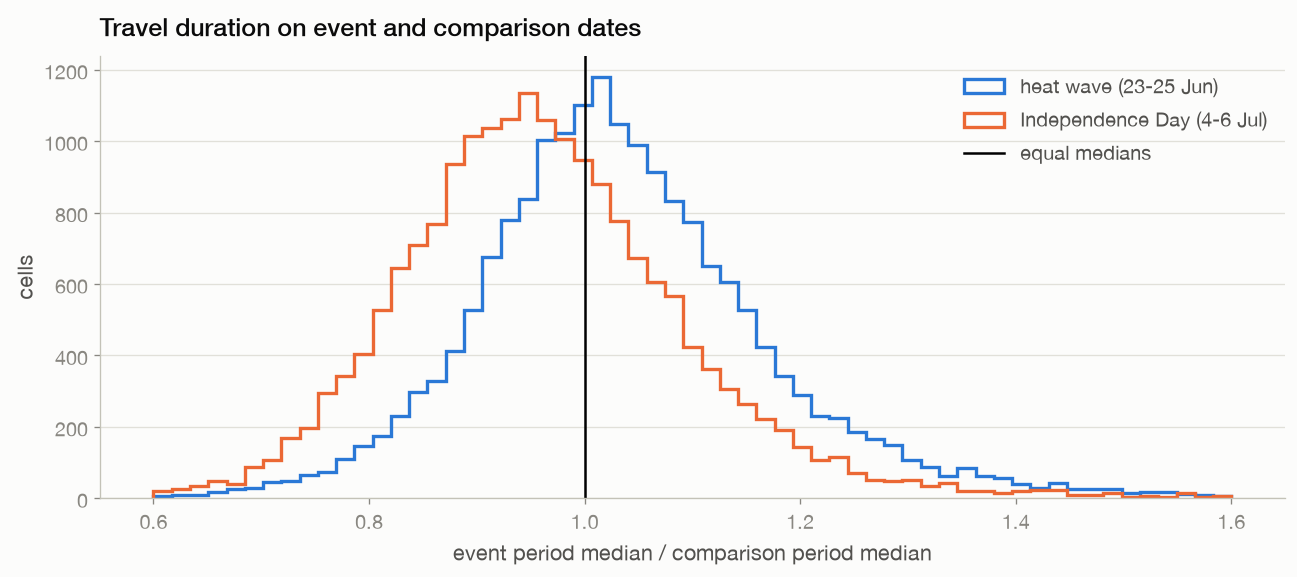

In [5]:
EVENTS = {"heat wave (23-25 Jun)": ["2025-06-23", "2025-06-24", "2025-06-25"],
          "Independence Day (4-6 Jul)": ["2025-07-04", "2025-07-05", "2025-07-06"]}

rows, per_cell = [], {}
for _name, _dates in EVENTS.items():
    _dl = ", ".join(f"DATE '{d}'" for d in _dates)
    _dows = ", ".join(str(pd.Timestamp(d).dayofweek) for d in _dates)   # Mon=0, as duckdb below
    _cmp = con.sql(f"""
    WITH ev AS (
      SELECT o, d, h, median(trip_time) AS t, count(*) AS n FROM bk
      WHERE dt IN ({_dl}) GROUP BY 1, 2, 3),
    ba AS (
      SELECT o, d, h, median(trip_time) AS t, count(*) AS n FROM bk
      WHERE dt NOT IN ({_dl}) AND (dayofweek(dt) + 6) % 7 IN ({_dows}) GROUP BY 1, 2, 3)
    SELECT ev.t / ba.t AS ratio, ev.n AS n_event
    FROM ev JOIN ba USING (o, d, h)
    WHERE ev.n >= 5 AND ba.n >= 5 ORDER BY o, d, h""").df()
    per_cell[_name] = _cmp.ratio
    rows.append({"event": _name, "event_days": ", ".join(d[5:] for d in _dates),
                 "cells": len(_cmp), "journeys": int(_cmp.n_event.sum()),
                 "median_ratio": round(_cmp.ratio.median(), 4),
                 "pct_change": round(100 * (_cmp.ratio.median() - 1), 2),
                 "p10": round(_cmp.ratio.quantile(0.10), 3),
                 "p90": round(_cmp.ratio.quantile(0.90), 3)})
EVENT_TT = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 5))
for _name, _r in per_cell.items():
    ax.hist(_r, bins=np.linspace(0.6, 1.6, 60), histtype="step", lw=2, label=_name)
ax.axvline(1.0, color="k", lw=1.5, label="equal medians")
ax.set_xlabel("event period median / comparison period median")
ax.set_ylabel("cells")
ax.set_title("Travel duration on event and comparison dates")
ax.legend()
fig.tight_layout()
EVENT_TT

#### Event period comparison

Median duration across the included cells is 2.33% higher during the June heat event and 4.76%
lower during the Independence Day period. The 10th and 90th percentiles show substantially wider
variation across individual cells.

These values describe the event dates relative to other dates. They do not measure the effect of
retaining the dates in the full two month fit. The next calculation compares fitted cell medians
with and without each event period.

#### Sensitivity of fitted cell medians

For each event, the table compares the median duration in every sufficiently observed taxi zone and
hour cell using all calibration dates with the median calculated after removing the event dates.
Cells require at least 30 trips in both calculations.

`median_shift_pct` summarizes the change across cells. `p90_abs_shift_pct` reports the 90th
percentile of the absolute change, and `cells_over_1pct` counts cells with an absolute change greater
than 1%.

In [6]:
rows = []
for _name, _dates in EVENTS.items():
    _dl = ", ".join(f"DATE '{d}'" for d in _dates)
    _cmp = con.sql(f'''
    WITH allday AS (
      SELECT o, d, h, median(trip_time) AS t, count(*) AS n FROM bk GROUP BY 1, 2, 3),
    without AS (
      SELECT o, d, h, median(trip_time) AS t, count(*) AS n FROM bk
      WHERE dt NOT IN ({_dl}) GROUP BY 1, 2, 3)
    SELECT 100 * (allday.t / without.t - 1) AS shift_pct
    FROM allday JOIN without USING (o, d, h)
    WHERE allday.n >= 30 AND without.n >= 30 ORDER BY o, d, h''').df()
    rows.append({"event": _name, "cells": len(_cmp),
                 "median_shift_pct": round(_cmp.shift_pct.median(), 3),
                 "p90_abs_shift_pct": round(_cmp.shift_pct.abs().quantile(0.90), 3),
                 "cells_over_1pct": int((_cmp.shift_pct.abs() > 1).sum())})
pd.DataFrame(rows)

,event,cells,median_shift_pct,p90_abs_shift_pct,cells_over_1pct
0,heat wave (23-25 Jun),34754,0.000,1.649,7132
1,Independence Day (4-6 Jul),34617,-0.126,1.792,8346


#### Findings

Including the June heat event changes the median fitted cell by 0.000% across cells. Including the
Independence Day period changes it by −0.126%. The 90th percentile of the absolute cell change is
1.649% for the heat event and 1.792% for the Independence Day period. An absolute change greater
than 1% occurs in 20.5% and 24.1% of cells, respectively.

The central results support retaining both event periods in the travel sample. Removing six dates
would reduce the observations available for sparsely populated cells while producing little change
in the median cell. Both periods therefore remain in the travel fit and remain excluded from the
demand fit.

This sensitivity analysis evaluates cell medians. The fitted artifact stores a distribution of
travel times, so the calculation does not establish that every stored percentile is unchanged.
Notebook 03 reports little change in duration dispersion during the heat event. A corresponding
distributional comparison is not available here for the Independence Day period.

The 2.33% heat result differs from the −1.45% estimate in Notebook 03 because the analyses use
different hours, minimum cell counts, and comparison dates. Both estimates remain within the 3%
materiality threshold used for the heat event.

## 3. Spatial aggregation of Brooklyn taxi zones

Brooklyn contains 61 TLC taxi zones. These zones are geographically coherent, but using them
directly would create 89,304 origin, destination, and hour cells. In the travel sample, the median
observed cell contains 22 trips and 43.5% of observed cells contain at least 30 trips.

The travel fit uses 30 trips as the threshold for estimating a cell directly before applying a
fallback. Aggregating adjacent taxi zones increases the number of observations per cell while
reducing spatial resolution. This section compares candidate zone counts and records the 20 zone map
used by the implemented artifacts.

### 3.1 Candidate counts and contiguity

Two clustering methods are compared. Centroid based k means repeatedly assigns taxi zone centroids
to the nearest cluster center. Ward clustering begins with individual taxi zones and successively
merges the pair that produces the smallest increase in within cluster variation. The implemented
Ward method also restricts each merge to neighboring groups. Neither method uses trip volume, travel
flows, zone area, neighborhood names, roads, or land use.

Two taxi zones are treated as neighbors when their polygons intersect after each has been buffered by
25 feet. The resulting 50 foot tolerance is the rule used by `eda/zoning.py`. The exact polygon
network is also evaluated to show the effect of this tolerance.

The comparison reports observed cell coverage, the share of observed cells with at least 30 trips,
median trips per cell, the range of taxi zone counts within each decision zone, and the number of
disconnected decision zones.

In [7]:
shp = gpd.read_file(f"zip://{RAW/'taxi_zones.zip'}!taxi_zones/taxi_zones.shp")
bk_shp = shp[shp.borough == "Brooklyn"].to_crs(2263).copy()
bk_shp["cx"] = bk_shp.geometry.centroid.x
bk_shp["cy"] = bk_shp.geometry.centroid.y
bk_shp["area_sqmi"] = bk_shp.geometry.area / 27_878_400
bk_shp["radius_mi"] = np.sqrt(bk_shp.area_sqmi / np.pi)
print(f"{len(bk_shp)} Brooklyn polygons; area in square miles: "
      f"median {bk_shp.area_sqmi.median():.2f}, largest {bk_shp.area_sqmi.max():.2f}")


def publish(lab, view="mp"):
    vals = ",".join(f"({a},{b})" for a, b in lab.items())
    con.execute(f"CREATE OR REPLACE TEMP VIEW {view} AS SELECT * FROM (VALUES {vals}) AS m(lid, z)")


def kmeans_labels(k):
    if k >= len(bk_shp):
        return dict(zip(bk_shp.LocationID, bk_shp.LocationID))
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(bk_shp[["cx", "cy"]])
    return dict(zip(bk_shp.LocationID, km.labels_))


def coverage(lab, k):
    publish(lab)
    r = con.sql("""
      SELECT count(*) AS observed, count(*) FILTER (WHERE n >= 30) AS ge30,
             count(*) FILTER (WHERE n >= 100) AS ge100, median(n) AS med
      FROM (SELECT mo.z AS zo, md.z AS zd, h, count(*) AS n
            FROM bk JOIN mp mo ON bk.o = mo.lid JOIN mp md ON bk.d = md.lid GROUP BY 1,2,3)
    """).fetchone()
    return {"zones": k, "possible": k * k * 24, "observed": r[0],
            "observed_pct": round(100 * r[0] / (k * k * 24), 1),
            "cells_ge30": r[1], "cells_ge30_pct": round(100 * r[1] / r[0], 1),
            "cells_ge100": r[2], "median_trips": int(r[3])}

61 Brooklyn polygons; area in square miles: median 0.98, largest 4.20


In [8]:
def adjacency_matrix(tolerance_ft):
    geom = bk_shp.geometry if tolerance_ft == 0 else bk_shp.geometry.buffer(tolerance_ft / 2)
    matrix = np.zeros((len(bk_shp), len(bk_shp)), dtype=int)
    for i in range(len(bk_shp)):
        for j in geom.sindex.query(geom.iloc[i], predicate="intersects"):
            if i != int(j):
                matrix[i, int(j)] = matrix[int(j), i] = 1
    return matrix


TOL_FT = 50
A_exact = adjacency_matrix(0)
A = adjacency_matrix(TOL_FT)
Asp = csr_matrix(A)
ids_ordered = list(bk_shp.LocationID)
pos = {lid: i for i, lid in enumerate(ids_ordered)}

print(f"exact polygon network: {A_exact.sum() // 2} neighboring pairs; "
      f"{connected_components(csr_matrix(A_exact), directed=False)[0]} connected component")
print(f"network with {TOL_FT} ft tolerance: {A.sum() // 2} neighboring pairs; "
      f"{connected_components(Asp, directed=False)[0]} connected component")


def ward_labels(k, require_contiguity=True):
    model = AgglomerativeClustering(
        n_clusters=k, connectivity=Asp if require_contiguity else None, linkage="ward"
    ).fit(bk_shp[["cx", "cy"]])
    return dict(zip(bk_shp.LocationID, model.labels_))


def contiguous_labels(k):
    return ward_labels(k, require_contiguity=True)


def same_partition(left, right):
    def groups(labels):
        return {
            frozenset(lid for lid, label in labels.items() if label == cluster_id)
            for cluster_id in set(labels.values())
        }
    return groups(left) == groups(right)


def split_report(lab):
    disconnected = 0
    sizes = []
    for cluster_id in sorted(set(lab.values())):
        members = [pos[lid] for lid, label in lab.items() if label == cluster_id]
        sizes.append(len(members))
        pieces = connected_components(
            csr_matrix(A[np.ix_(members, members)]), directed=False
        )[0]
        disconnected += int(pieces > 1)
    return disconnected, min(sizes), max(sizes)

exact polygon network: 155 neighboring pairs; 1 connected component
network with 50 ft tolerance: 156 neighboring pairs; 1 connected component


In [9]:
rows = []

baseline = kmeans_labels(61)
disconnected, zone_min, zone_max = split_report(baseline)
cov = coverage(baseline, 61)
rows.append({"method": "TLC taxi zones", **cov,
             "disconnected": disconnected,
             "taxi_zones_min": zone_min, "taxi_zones_max": zone_max})

for method, label_function in (
    ("centroid k means", kmeans_labels),
    ("contiguous Ward", contiguous_labels),
):
    for k in (30, 24, 20, 16, 12):
        labels = label_function(k)
        disconnected, zone_min, zone_max = split_report(labels)
        cov = coverage(labels, k)
        rows.append({"method": method, **cov,
                     "disconnected": disconnected,
                     "taxi_zones_min": zone_min, "taxi_zones_max": zone_max})

display(pd.DataFrame(rows)[[
    "method", "zones", "observed_pct", "cells_ge30_pct", "median_trips",
    "taxi_zones_min", "taxi_zones_max", "disconnected"
]])

constraint_checks = []
for k in (30, 24, 20, 16, 12):
    ward = ward_labels(k, require_contiguity=False)
    contiguous = ward_labels(k, require_contiguity=True)
    constraint_checks.append({
        "zones": k,
        "same Ward partition": same_partition(ward, contiguous),
        "unconstrained disconnected": split_report(ward)[0],
        "constrained disconnected": split_report(contiguous)[0],
    })

display(pd.DataFrame(constraint_checks))

,method,zones,observed_pct,cells_ge30_pct,median_trips,taxi_zones_min,taxi_zones_max,disconnected
0,TLC taxi zones,61,91.5,43.5,22,1,1,0
1,centroid k means,30,98.0,70.3,85,1,5,0
2,centroid k means,24,98.1,78.1,126,1,5,0
3,centroid k means,20,98.3,83.8,198,1,6,0
4,centroid k means,16,98.8,89.1,436,1,7,0
5,centroid k means,12,100.0,98.3,656,3,9,0
6,contiguous Ward,30,97.9,71.7,83,1,3,0
7,contiguous Ward,24,98.4,79.5,133,1,6,0
8,contiguous Ward,20,98.5,85.3,200,1,6,0
9,contiguous Ward,16,100.0,97.1,334,2,6,0


,zones,same Ward partition,unconstrained disconnected,constrained disconnected
0,30,True,0,0
1,24,True,0,0
2,20,True,0,0
3,16,True,0,0
4,12,True,0,0


### Findings

The 61 TLC taxi zones are valid geographic units. Their limitation is sample size: the median cell
contains 22 trips, and 43.5% of observed cells meet the 30 trip threshold used for direct estimation.

At 20 decision zones, contiguous Ward clustering observes 98.5% of possible cells, 85.3% of observed
cells meet the threshold, and the median cell contains 200 trips. The corresponding centroid k means
values are 98.3%, 83.8%, and 198 trips.

The difference between the k means and Ward maps comes from the clustering procedure. K means can
reassign a taxi zone as cluster centers change. Ward clustering makes a sequence of merges and does
not revisit an earlier merge. The two procedures can therefore produce different boundaries from the
same centroid coordinates.

Ward clustering was also run without the adjacency restriction. The constrained and unconstrained
Ward partitions are identical at every tested count from 12 through 30, and both are geographically
connected. The adjacency restriction does not change the zones in this dataset. It records a required
property of the zoning procedure and prevents a disconnected group if the inputs or selected count
change. The exact polygon network is already connected; the 50 foot tolerance adds one neighboring
pair and does not change network connectivity.

The evidence does not identify 20 as a unique optimum. It provides a compromise between the spatial
resolution of 24 or 30 zones and the higher cell coverage of 12 or 16 zones. The implementation uses
20 zones, and Section 9 evaluates sensitivity to alternative counts.

### Candidate maps

The maps show the contiguous Ward solution at five candidate counts together with the 61 original
taxi zones. They illustrate the spatial resolution lost as taxi zones are aggregated.

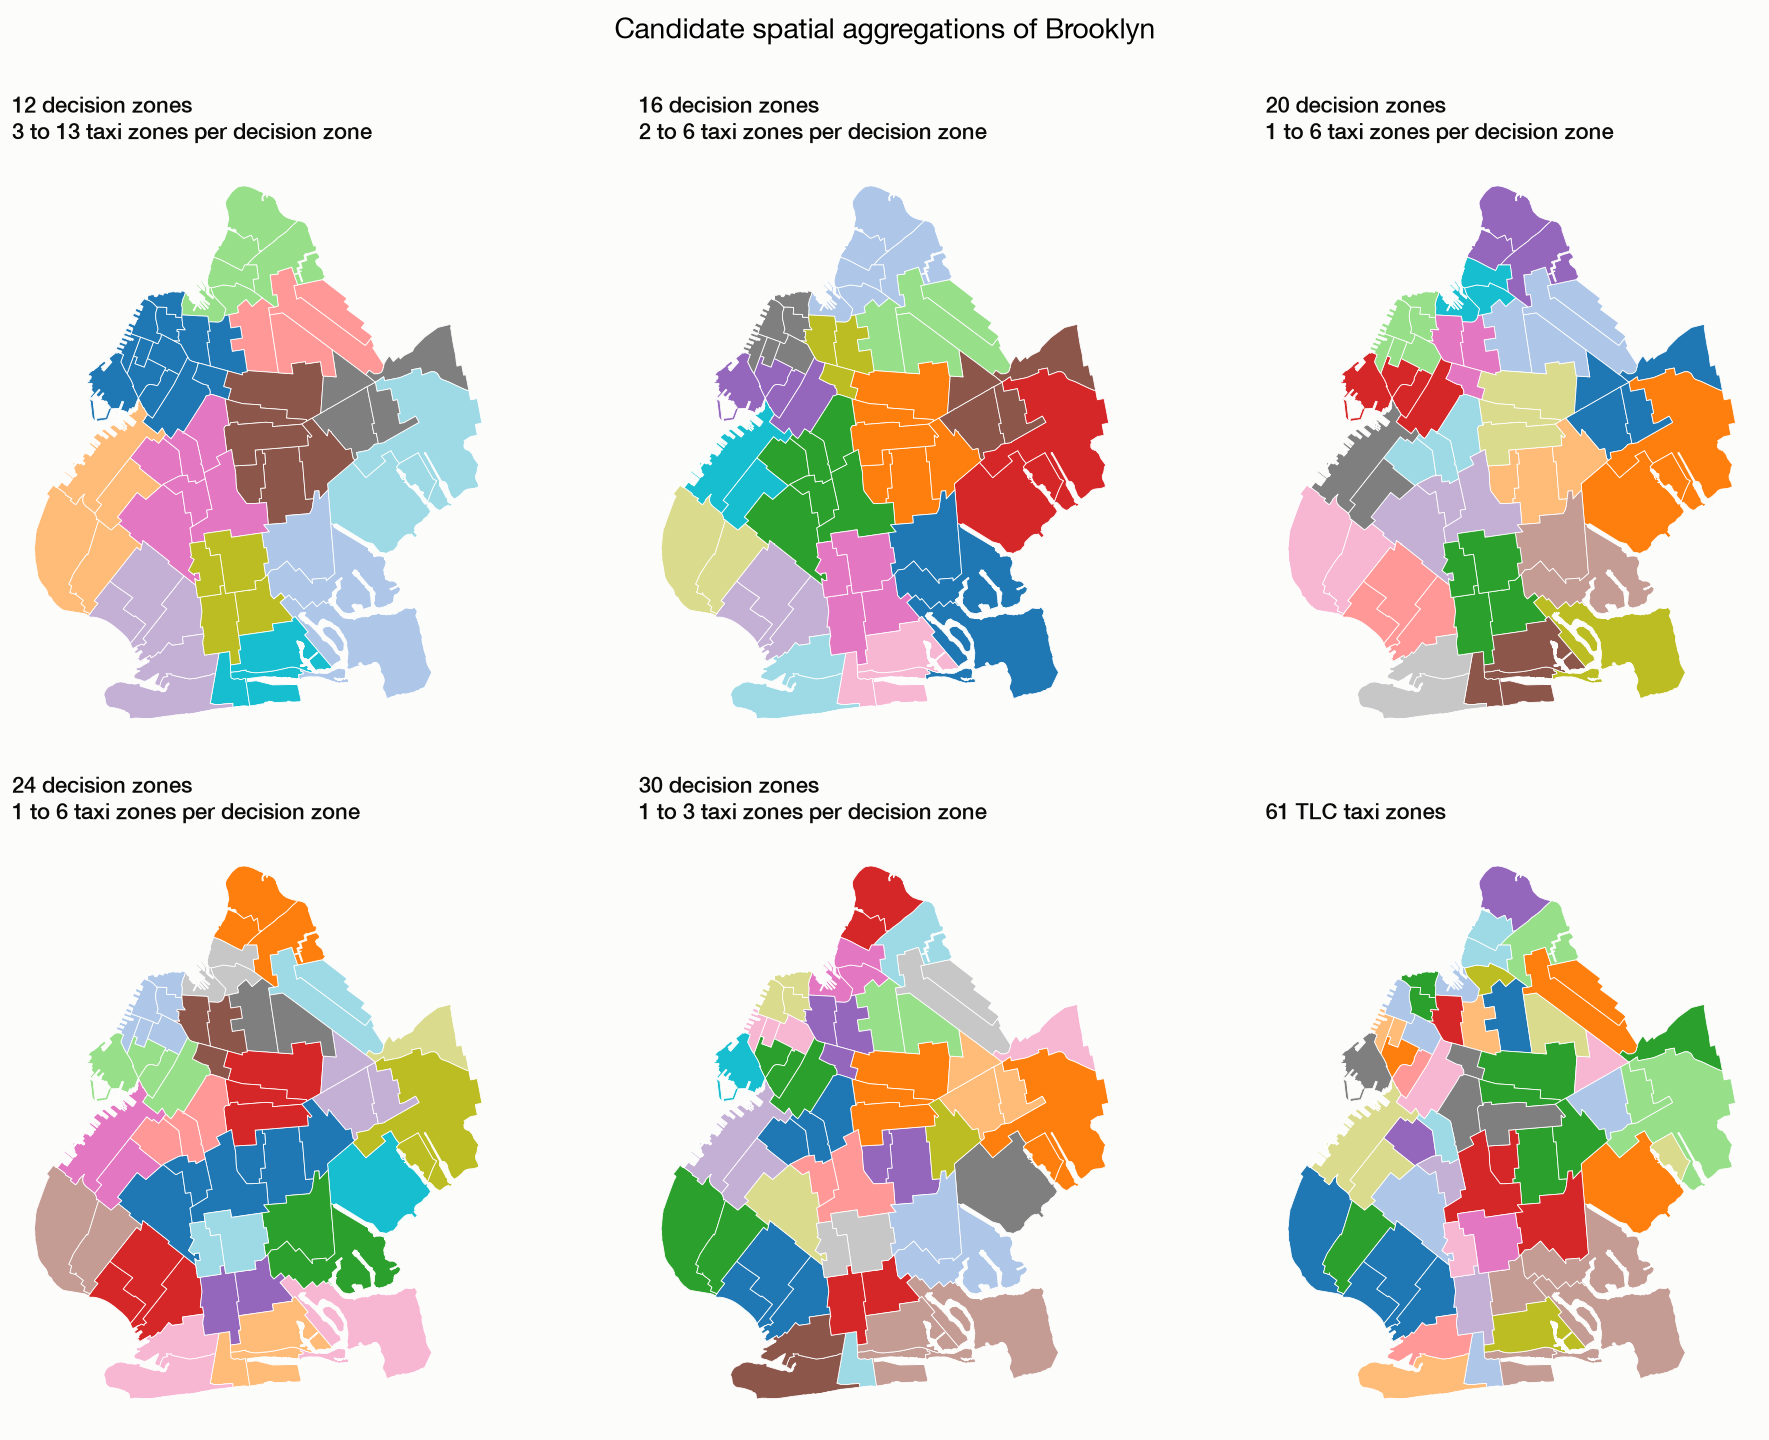

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 12))
for ax, k in zip(axes.ravel(), (12, 16, 20, 24, 30, 61)):
    g = bk_shp.copy()
    labels = kmeans_labels(k) if k >= len(bk_shp) else contiguous_labels(k)
    g["place"] = g.LocationID.map(labels)
    g.plot(column="place", ax=ax, cmap="tab20", edgecolor="white", linewidth=0.5)
    if k < len(bk_shp):
        disconnected, zone_min, zone_max = split_report(labels)
        ax.set_title(
            f"{k} decision zones\n{zone_min} to {zone_max} taxi zones per decision zone",
            fontsize=13,
        )
    else:
        ax.set_title("61 TLC taxi zones", fontsize=13)
    ax.set_axis_off()
fig.suptitle("Candidate spatial aggregations of Brooklyn", fontsize=17, y=1.0)
fig.tight_layout()

The maps show progressively coarser spatial units as the decision zone count falls. The method uses
centroid coordinates and polygon adjacency only. Apparent alignment with neighborhoods, roads, parks,
or travel patterns is not an input to the clustering procedure.

### 3.2 Implemented 20 zone map

The implemented artifacts use one deterministic 20 zone map. The map is created once and registered
as the `mp` SQL view used by all subsequent analyses in this notebook.

In [11]:
N_PLACES = 20
ZONING = contiguous_labels(N_PLACES)
publish(ZONING)

zone_names = bk_shp.set_index("LocationID")["zone"]
place_of = pd.Series(ZONING, name="place")
places = (pd.DataFrame({"zone": zone_names, "place": place_of})
          .dropna().astype({"place": int})
          .groupby("place")["zone"].apply(lambda s: ", ".join(sorted(s))))

disconnected, zone_min, zone_max = split_report(ZONING)
print(f"IMPLEMENTED DIVISION: {N_PLACES} decision zones; {disconnected} disconnected; "
      f"{zone_min} to {zone_max} taxi zones per decision zone")
print("Section 9 evaluates sensitivity to 16 and 24 decision zones.")
print()
for place, names in places.items():
    print(f"  decision zone {place:>2}: {names}")

IMPLEMENTED DIVISION: 20 decision zones; 0 disconnected; 1 to 6 taxi zones per decision zone
Section 9 evaluates sensitivity to 16 and 24 decision zones.

  decision zone  0: Brownsville, Cypress Hills, East New York/Pennsylvania Avenue, Ocean Hill
  decision zone  1: Bedford, Bushwick North, Bushwick South, Stuyvesant Heights
  decision zone  2: Canarsie, East New York, Starrett City
  decision zone  3: East Flatbush/Farragut, East Flatbush/Remsen Village, Erasmus
  decision zone  4: Homecrest, Madison, Midwood, Ocean Parkway South
  decision zone  5: Boerum Hill, Brooklyn Heights, Cobble Hill, Columbia Street, DUMBO/Vinegar Hill, Downtown Brooklyn/MetroTech
  decision zone  6: Carroll Gardens, Gowanus, Park Slope, Red Hook
  decision zone  7: Bath Beach, Bensonhurst East, Bensonhurst West
  decision zone  8: East Williamsburg, Greenpoint, Williamsburg (North Side)
  decision zone  9: Borough Park, Flatbush/Ditmas Park, Kensington
  decision zone 10: Brighton Beach, Manhattan Beach, S

The implemented map contains 20 connected decision zones, each comprising between one and six TLC
taxi zones. `eda/fit_travel.py` writes the same mapping to
`config/zoning/brooklyn-20-v1.csv` with the fitted travel artifacts. Comparisons between policy
results therefore depend on the zoning version as well as the fitted duration and distance files.

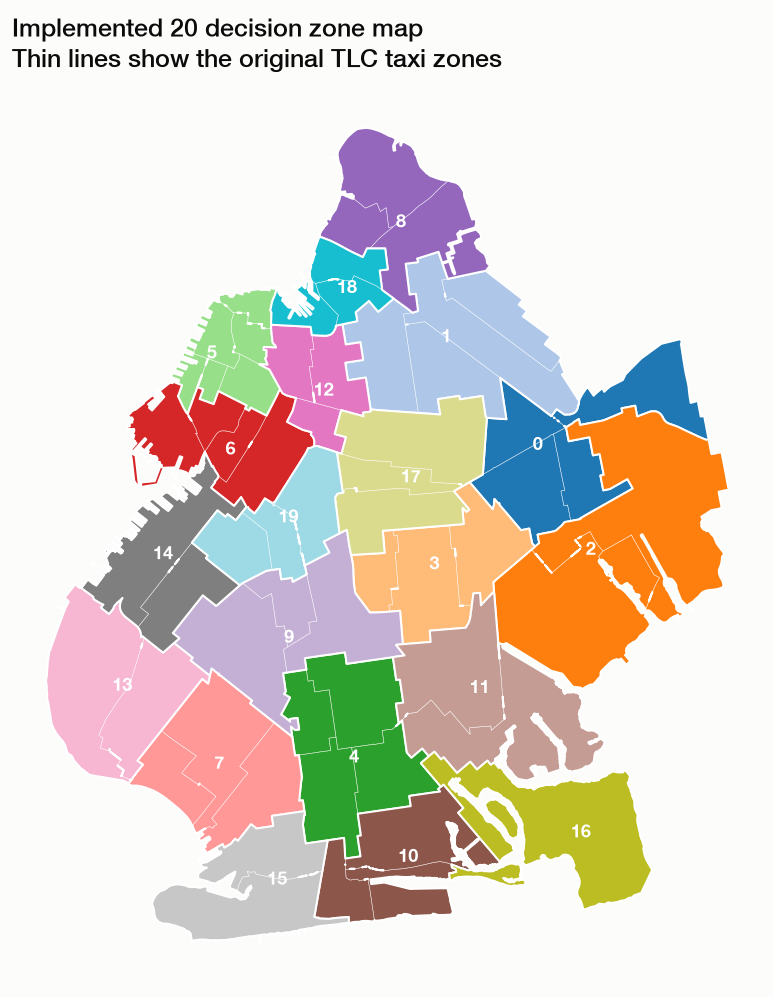

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 8.5))
g = bk_shp.copy()
g["place"] = g.LocationID.map(ZONING)
merged = g.dissolve(by="place")
merged.plot(ax=ax, column=merged.index, cmap="tab20", edgecolor="white", linewidth=1.2)
g.boundary.plot(ax=ax, color="white", linewidth=0.3, alpha=0.7)
for decision_zone, geometry in zip(merged.index, merged.geometry):
    point = geometry.representative_point()
    ax.annotate(str(decision_zone), (point.x, point.y), ha="center", va="center",
                fontsize=11, color="white", weight="bold")
ax.set_title("Implemented 20 decision zone map\nThin lines show the original TLC taxi zones")
ax.set_axis_off()
fig.tight_layout()

## 4. Sensitivity to extreme travel records

The travel artifacts retain all records in the working sample. This matches `eda/fit_travel.py`,
which requires positive duration and distance and excludes matched shared rides but applies no
additional outlier filter.

Several record level measures can identify unusual observations: implied speed, duration relative to
the taxi zone pair median, distance relative to the pair median, and distance relative to a spatial
reference. These measures do not establish that a record is invalid. Slow trips and long routes can
occur, and the data do not provide an independent validity label.

The spatial reference combines the distance between taxi zone centroids with the radii of circles
having the same areas as the two zones. It is a scale measure rather than a geographic upper bound.
Taxi zones are irregular, and road distance can exceed straight line distance. The reference is
therefore used only to flag records for sensitivity analysis.

This section reports the prevalence of the flags and measures their effect on fitted duration
statistics and mean route distances.


In [13]:
lids = bk_shp.LocationID.to_numpy().astype(int)
xy = bk_shp[["cx", "cy"]].to_numpy().astype(float)
rad = bk_shp.radius_mi.to_numpy().astype(float)
sep = np.sqrt((xy[:, 0][:, None] - xy[:, 0])**2 + (xy[:, 1][:, None] - xy[:, 1])**2) / 5280.0
np.fill_diagonal(sep, 0.0)
area_scale = sep + rad[:, None] + rad[None, :]
crow = sep.copy()
np.fill_diagonal(crow, rad)

con.register("geo", pd.DataFrame({
    "o": np.repeat(lids, len(lids)),
    "d": np.tile(lids, len(lids)),
    "crow_mi": crow.ravel(),
    "area_scale_mi": area_scale.ravel(),
}))
print(f"geometry table: {len(lids)**2:,} taxi zone pairs")
print(f"  largest centroid separation: {sep.max():.2f} mi")
print(f"  largest equal area distance scale: {area_scale.max():.2f} mi")

con.execute("""
CREATE OR REPLACE VIEW checked AS
WITH route AS (
    SELECT o, d, median(trip_time) AS med_t, median(trip_miles) AS med_mi,
           count(*) AS n
    FROM bk GROUP BY 1, 2
)
SELECT bk.*, geo.crow_mi, geo.area_scale_mi,
       bk.trip_miles / geo.crow_mi                 AS detour,
       bk.trip_miles / geo.area_scale_mi           AS vs_area_scale,
       bk.trip_time / route.med_t                  AS t_vs_peers,
       bk.trip_miles / route.med_mi                AS mi_vs_peers,
       bk.trip_miles / (bk.trip_time / 3600.0)     AS mph,
       route.n                                     AS pair_trips
FROM bk JOIN geo USING (o, d) JOIN route USING (o, d)
""")
print("view `checked` built")


geometry table: 3,721 taxi zone pairs
  largest centroid separation: 10.72 mi
  largest equal area distance scale: 12.09 mi
view `checked` built


### 4.1 Diagnostic flags

Four thresholds describe the extreme observations. The route relative thresholds are calculated only
for taxi zone pairs with at least 100 trips. The rules overlap; the final row reports their union.


In [14]:
RULES = [
    ("implied speed above 70 mph", "mph > 70"),
    ("implied speed below 3 mph", "mph < 3"),
    ("duration above 6 times the taxi zone pair median",
     "t_vs_peers > 6 AND pair_trips >= 100"),
    ("distance above 6 times the taxi zone pair median",
     "mi_vs_peers > 6 AND pair_trips >= 100"),
    ("distance above 3 times the equal area scale", "vs_area_scale > 3"),
    ("any diagnostic flag",
     "mph > 70 OR mph < 3 OR vs_area_scale > 3 OR "
     "(pair_trips >= 100 AND (t_vs_peers > 6 OR mi_vs_peers > 6))"),
]
total = con.sql("SELECT count(*) FROM checked").fetchone()[0]
rows = []
for name, cond in RULES:
    r = con.sql(f"""
        SELECT count(*), median(trip_time) / 60, median(trip_miles), median(mph)
        FROM checked WHERE {cond}
    """).fetchone()
    rows.append({
        "rule": name,
        "trips": r[0],
        "share_pct": round(100 * r[0] / total, 3),
        "median_duration_min": round(float(r[1]), 1) if r[0] else None,
        "median_distance_mi": round(float(r[2]), 2) if r[0] else None,
        "median_speed_mph": round(float(r[3]), 2) if r[0] else None,
    })

display(pd.DataFrame(rows))

longest_same = con.sql("""
    SELECT trip_miles, trip_time / 60 AS minutes, mph
    FROM checked WHERE o = d ORDER BY trip_miles DESC LIMIT 1
""").fetchone()
print(
    f"Longest recorded trip within one taxi zone: {longest_same[0]:.2f} mi, "
    f"{longest_same[1]:.1f} min, {longest_same[2]:.1f} mph"
)


,rule,trips,share_pct,median_duration_min,median_distance_mi,median_speed_mph
0,implied speed above 70 mph,4,0.000,0.5,0.61,88.20
1,implied speed below 3 mph,16488,0.210,12.3,0.48,2.47
2,duration above 6 times the taxi zone pair median,7399,0.094,53.7,8.13,9.15
3,distance above 6 times the taxi zone pair median,7782,0.099,49.8,8.75,10.84
4,distance above 3 times the equal area scale,16577,0.211,38.0,6.13,9.85
5,any diagnostic flag,33438,0.426,24.6,2.48,4.30


Longest recorded trip within one taxi zone: 450.59 mi, 490.0 min, 55.2 mph


Four records imply an average speed above 70 mph. The union of all diagnostic flags contains 33,438
records, or 0.426% of the working sample. The longest trip recorded within a single taxi zone is
450.59 miles. Its duration of 490 minutes places it below the 70 mph threshold, so a speed rule alone
does not identify it.

The flags contain likely data errors as well as potentially valid congestion and detours. The current
artifacts retain them. The following comparisons quantify the effect of that choice.


In [15]:
TIER_A = "TRUE"  # implemented artifact sample; retained for later notebook queries
TIER_B = (
    "NOT (mph > 70 OR mph < 3 OR vs_area_scale > 3 OR "
    "(pair_trips >= 100 AND (t_vs_peers > 6 OR mi_vs_peers > 6)))"
)
CLEAN = TIER_A
CLEAN_AB = TIER_B  # stricter sensitivity sample

for name, cond in (("implemented sample", TIER_A),
                   ("sample excluding all diagnostic flags", CLEAN_AB)):
    n = con.sql(f"SELECT count(*) FROM checked WHERE {cond}").fetchone()[0]
    print(f"{name:<40} {n:>10,}  ({100 * n / total:.3f}%)")


implemented sample                        7,857,311  (100.000%)


sample excluding all diagnostic flags     7,823,873  (99.574%)


### 4.2 Sensitivity of duration statistics

The comparison uses origin, destination, and hour cells with at least 300 trips in the implemented
sample. Each statistic is calculated once with the full sample and once after removing every flagged
record. Changes are then summarized across cells.


The reported values are the median cell statistic in minutes, the share of cells with an absolute
change above 1%, and the 90th and 99th percentiles of the absolute percentage change.


In [16]:
cell_stats = con.sql(f"""
WITH a AS (
    SELECT mo.z AS zo, md.z AS zd, h,
           count(*) AS n, avg(trip_time) AS mean_t,
           quantile_cont(trip_time, 0.5) AS p50,
           quantile_cont(trip_time, 0.95) AS p95,
           quantile_cont(trip_time, 0.99) AS p99
    FROM checked
    JOIN mp mo ON checked.o = mo.lid
    JOIN mp md ON checked.d = md.lid
    WHERE {TIER_A}
    GROUP BY 1, 2, 3 HAVING count(*) >= 300
),
b AS (
    SELECT mo.z AS zo, md.z AS zd, h,
           avg(trip_time) AS mean_t,
           quantile_cont(trip_time, 0.5) AS p50,
           quantile_cont(trip_time, 0.95) AS p95,
           quantile_cont(trip_time, 0.99) AS p99
    FROM checked
    JOIN mp mo ON checked.o = mo.lid
    JOIN mp md ON checked.d = md.lid
    WHERE {CLEAN_AB}
    GROUP BY 1, 2, 3
)
SELECT a.zo, a.zd, a.h, a.n,
       a.mean_t AS a_mean, b.mean_t AS b_mean,
       a.p50 AS a_p50, b.p50 AS b_p50,
       a.p95 AS a_p95, b.p95 AS b_p95,
       a.p99 AS a_p99, b.p99 AS b_p99
FROM a JOIN b USING (zo, zd, h)
""").df()
print(f"{len(cell_stats):,} cells with at least 300 trips")

rows = []
for label, ca, cb in (
    ("mean", "a_mean", "b_mean"),
    ("median", "a_p50", "b_p50"),
    ("95th percentile", "a_p95", "b_p95"),
    ("99th percentile", "a_p99", "b_p99"),
):
    change = 100 * (cell_stats[cb] - cell_stats[ca]) / cell_stats[ca]
    absolute = change.abs()
    rows.append({
        "statistic": label,
        "implemented_min": round(float(cell_stats[ca].median() / 60), 2),
        "flags_excluded_min": round(float(cell_stats[cb].median() / 60), 2),
        "cells_over_1pct": round(float(100 * (absolute > 1).mean()), 1),
        "p90_abs_change_pct": round(float(absolute.quantile(0.90)), 2),
        "p99_abs_change_pct": round(float(absolute.quantile(0.99)), 2),
    })
pd.DataFrame(rows)


3,979 cells with at least 300 trips


,statistic,implemented_min,flags_excluded_min,cells_over_1pct,p90_abs_change_pct,p99_abs_change_pct
0,mean,15.48,15.45,11.5,1.38,5.54
1,median,14.73,14.73,0.9,0.24,0.96
2,95th percentile,26.43,26.38,12.6,1.44,6.96
3,99th percentile,32.98,32.68,25.0,6.13,31.24


The cell median is stable: 0.9% of cells change by more than 1%, and the 99th percentile of the
absolute change is 0.96%. The upper tail is more sensitive. Excluding the flagged records changes the
99th percentile by more than 1% in 25.0% of cells; the 90th percentile of the absolute change is
6.13%, and the 99th percentile is 31.24%.

Retaining the flagged observations therefore has little effect on typical duration but can materially
increase the upper tail of individual cells.


### 4.3 Sensitivity of mean route distance

The distance artifact stores the arithmetic mean recorded distance for each observed decision zone
pair. This comparison recalculates the 400 route means after removing every flagged record.


The summary reports the distribution of absolute percentage changes across routes. The second table
lists the five routes with the largest changes.


In [17]:
distance_sensitivity = con.sql(f"""
WITH a AS (
    SELECT mo.z AS zo, md.z AS zd, count(*) AS n, avg(trip_miles) AS mean_mi
    FROM checked
    JOIN mp mo ON checked.o = mo.lid
    JOIN mp md ON checked.d = md.lid
    WHERE {TIER_A}
    GROUP BY 1, 2
),
b AS (
    SELECT mo.z AS zo, md.z AS zd, count(*) AS n, avg(trip_miles) AS mean_mi
    FROM checked
    JOIN mp mo ON checked.o = mo.lid
    JOIN mp md ON checked.d = md.lid
    WHERE {CLEAN_AB}
    GROUP BY 1, 2
)
SELECT a.zo, a.zd, a.n,
       a.mean_mi AS implemented_mean_mi,
       b.n AS flags_excluded_n,
       b.mean_mi AS flags_excluded_mean_mi,
       100 * (b.mean_mi - a.mean_mi) / a.mean_mi AS change_pct
FROM a JOIN b USING (zo, zd)
""").df()

absolute = distance_sensitivity.change_pct.abs()
summary = pd.DataFrame([{
    "routes": len(distance_sensitivity),
    "median_abs_change_pct": round(float(absolute.median()), 3),
    "p90_abs_change_pct": round(float(absolute.quantile(0.90)), 3),
    "p95_abs_change_pct": round(float(absolute.quantile(0.95)), 3),
    "p99_abs_change_pct": round(float(absolute.quantile(0.99)), 3),
    "maximum_abs_change_pct": round(float(absolute.max()), 3),
    "routes_over_1pct": int((absolute > 1).sum()),
}])
display(summary)

top = distance_sensitivity.loc[absolute.nlargest(5).index].copy()
top["implemented_mean_mi"] = top.implemented_mean_mi.round(3)
top["flags_excluded_mean_mi"] = top.flags_excluded_mean_mi.round(3)
top["change_pct"] = top.change_pct.round(3)
display(top)


,routes,median_abs_change_pct,p90_abs_change_pct,p95_abs_change_pct,p99_abs_change_pct,maximum_abs_change_pct,routes_over_1pct
0,400,0.083,0.582,2.114,5.069,36.554,31


,zo,zd,n,implemented_mean_mi,flags_excluded_n,flags_excluded_mean_mi,change_pct
347,16,16,73,2.447,67,1.553,-36.554
39,19,19,3629,1.370,3462,1.197,-12.604
82,18,18,42413,0.964,41057,0.903,-6.297
237,5,5,110578,1.188,107682,1.128,-5.098
266,0,0,144490,1.317,141940,1.250,-5.068


The median absolute change in route mean distance is 0.083%, and 31 of 400 routes change by more than
1%. The effect is concentrated in a small number of routes. The largest change occurs for decision
zone 16 to itself, where the mean falls from 2.447 to 1.553 miles after six flagged records are
removed, a reduction of 36.6%.

The existing distance artifact reports this route as 3,938 meters, consistent with the unfiltered
mean. Sparse within zone routes are therefore sensitive to extreme recorded distances. This is a
limitation of the current distance artifact because every observed route uses its arithmetic mean,
regardless of its sample size.


## 5. Representation of cell duration distributions

Each origin, destination, and hour cell must represent a distribution of travel times. The comparison
includes three empirical quantile grids, fitted lognormal and gamma distributions, and a kernel density
benchmark. The kernel density estimate is included as a flexible reference and is not implemented by
the travel artifact.

The evaluation uses blocked cross validation on a stratified sample of well observed cells. The primary
metric is pinball loss at the 99th percentile because it evaluates the upper quantile directly and uses
all held out observations. Continuous ranked probability score, calibration, empirical quantile error,
and mean error provide supplementary evidence.

Statistical comparisons use the cell as the independent unit. Five folds from the same cell are first
combined, after which cells are resampled to obtain paired intervals. When an interval includes zero,
the comparison does not establish an accuracy difference.


### 5.1 Evaluation sample

Eligible cells contain at least 400 trips observed on at least 25 dates. They are stratified by whether
the origin and destination are the same decision zone, trip count, centroid distance, and time of day.
Up to three cells are sampled from each observed stratum.

This design gives equal representation to different parts of the matrix rather than weighting the
comparison toward the busiest routes. It evaluates well observed cells; the treatment of sparse and
unobserved cells is examined separately in Section 8.


In [18]:
cell_index = con.sql(f"""
SELECT mo.z AS zo, md.z AS zd, h, count(*) AS n,
       avg(crow_mi) AS crow_mi, count(DISTINCT dt) AS days
FROM checked
JOIN mp mo ON checked.o = mo.lid
JOIN mp md ON checked.d = md.lid
WHERE {TIER_A}
GROUP BY 1, 2, 3
HAVING count(*) >= 400 AND count(DISTINCT dt) >= 25
ORDER BY zo, zd, h
""").df()
print(f"{len(cell_index):,} eligible cells")

cell_index["kind"] = np.where(cell_index.zo == cell_index.zd, "same zone", "between zones")
cell_index["volume"] = pd.qcut(cell_index.n, 3, labels=["low", "middle", "high"])
cell_index["distance"] = pd.qcut(
    cell_index.crow_mi.rank(method="first"), 3, labels=["near", "middle", "far"]
)
cell_index["time_of_day"] = pd.cut(
    cell_index.h, [-1, 5, 11, 17, 23],
    labels=["night", "morning", "afternoon", "evening"],
)

PER_STRATUM = 3
picks = [
    group.sample(min(len(group), PER_STRATUM), random_state=SEED)
    for _, group in cell_index.groupby(
        ["kind", "volume", "distance", "time_of_day"], observed=True
    )
]
sample = pd.concat(picks).reset_index(drop=True)
print(
    f"sample: {len(sample)} cells, "
    f"{sample.groupby(['kind', 'volume', 'distance', 'time_of_day'], observed=True).ngroups} strata, "
    f"{sample.groupby(['zo', 'zd']).ngroups} decision zone pairs"
)

sample.groupby("kind", observed=True).agg(
    cells=("n", "size"),
    median_trips=("n", "median"),
    minimum_trips=("n", "min"),
    maximum_trips=("n", "max"),
).reset_index()


3,398 eligible cells
sample: 135 cells, 45 strata, 94 decision zone pairs


,kind,cells,median_trips,minimum_trips,maximum_trips
0,between zones,108,1282.5,406,8088
1,same zone,27,1900.0,458,17050


The eligibility criteria produce 3,398 cells. The stratified sample contains 135 cells from 45 strata
and 94 decision zone pairs. Twenty percent are within zone cells. Each sampled cell contributes equally
to the comparison after its five validation folds are combined.


### 5.2 Observed distribution shapes

The figure shows a pooled sample and the highest volume cell of each cell type. Each row contains the
raw duration histogram, the histogram after a logarithmic transformation, and a normal quantile plot
of the transformed values. These examples describe the distributions and do not determine the storage
choice.


,population,journeys,p10_min,median_min,p90_min,p90_over_p10,skew_raw,skew_of_log
0,All Brooklyn journeys pooled,200000,5.58,12.60,26.93,4.82,1.78,-0.16
1,"Within Bedford and 3 more, hour 23",23911,4.65,8.62,14.53,3.13,2.61,-0.32
2,East Williamsburg and 2 more to Bedford and 3 ...,11727,8.62,15.13,22.73,2.64,0.63,-0.73


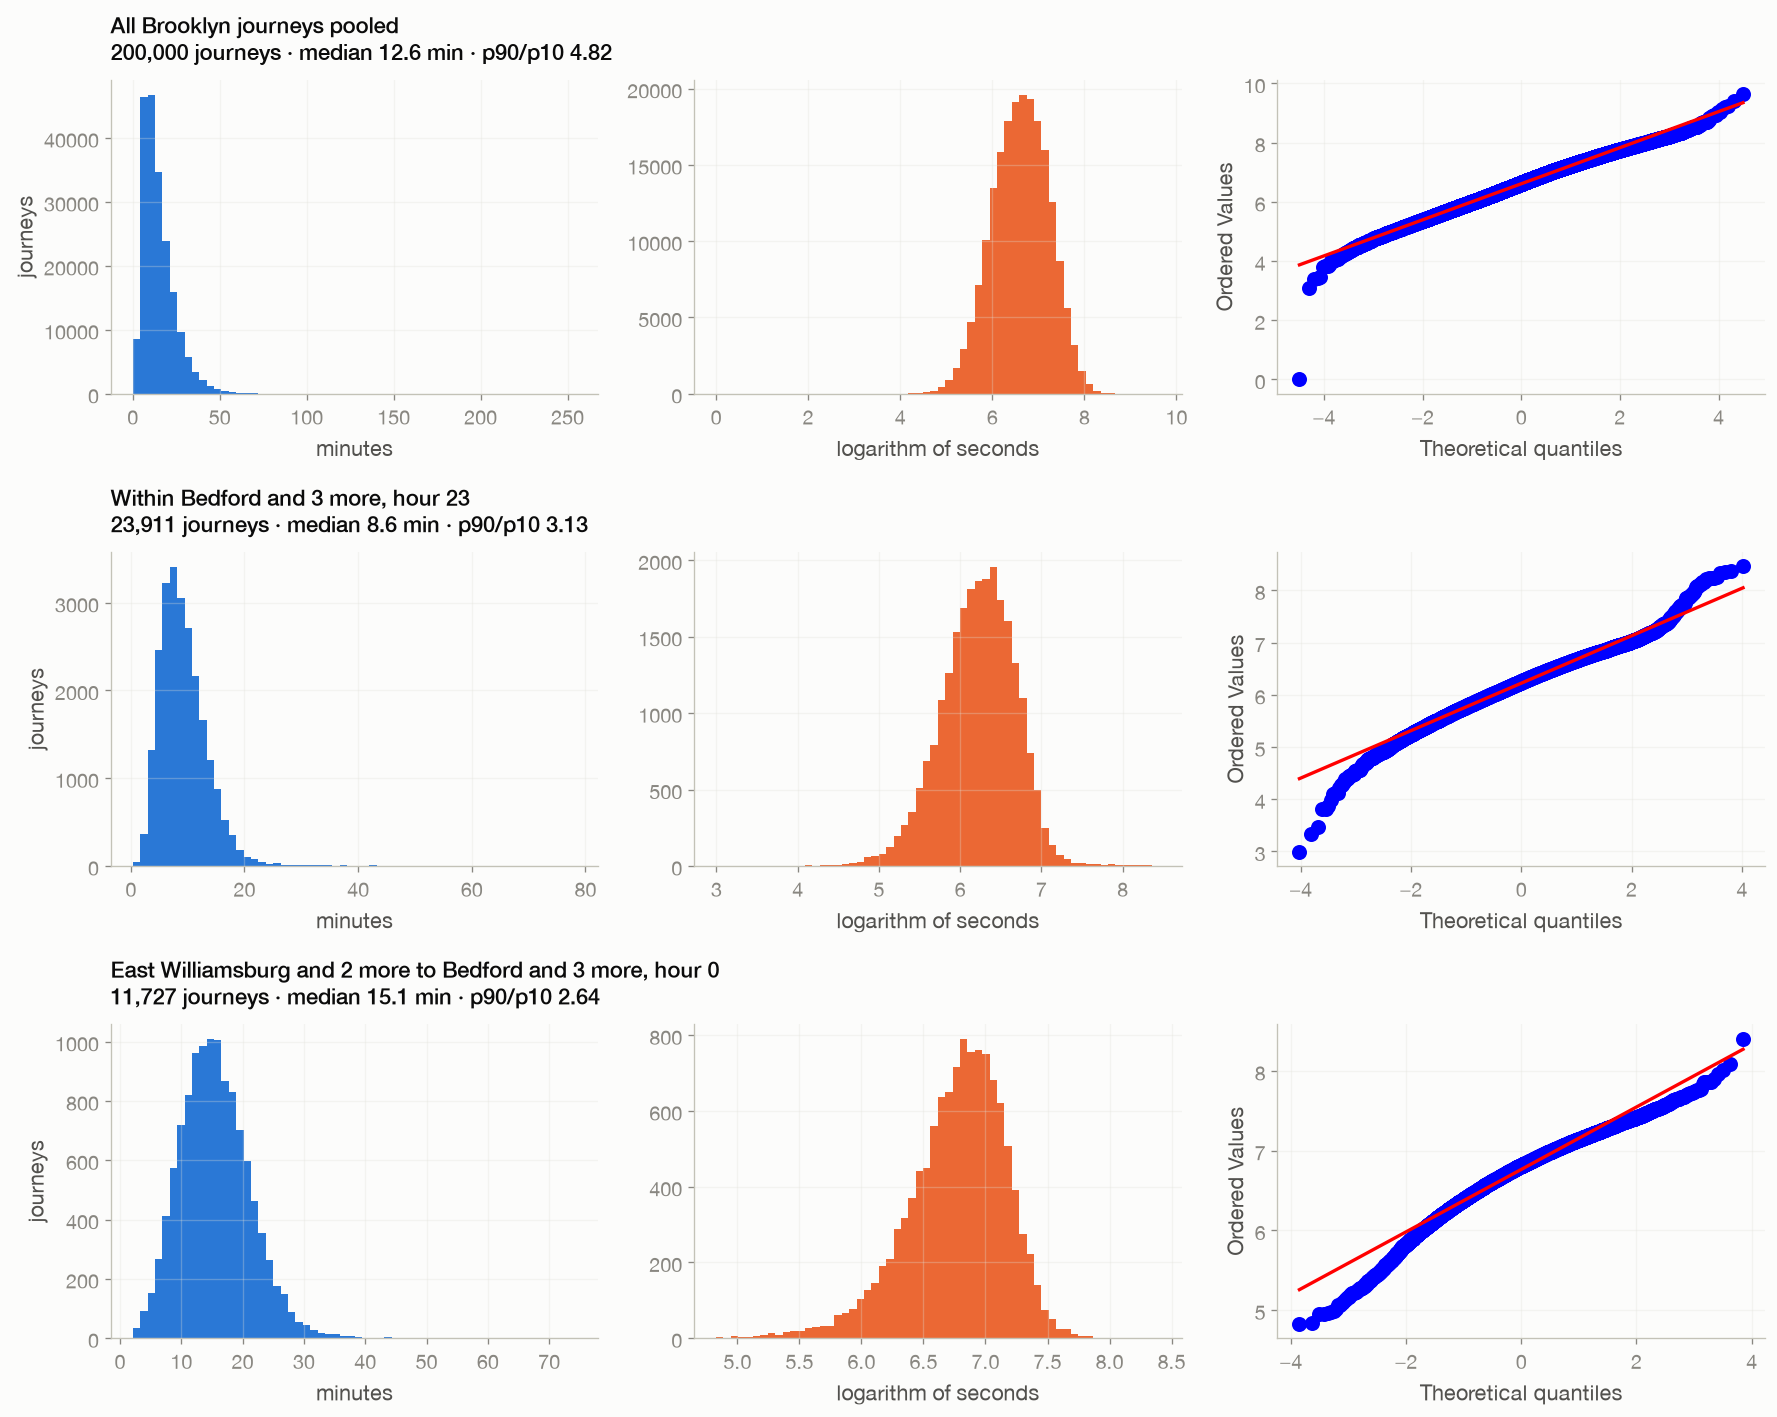

In [19]:
def cell_durations(zo, zd, h):
    return con.sql(f'''SELECT trip_time FROM checked
      JOIN mp mo ON checked.o = mo.lid JOIN mp md ON checked.d = md.lid
      WHERE mo.z = {zo} AND md.z = {zd} AND h = {h} AND {TIER_A}
      ORDER BY trip_time''').df().trip_time.values.astype(float)

def place_name(p):
    zs = sorted(bk_shp.set_index("LocationID").loc[[l for l, c in ZONING.items() if c == p], "zone"])
    return zs[0] + (f" and {len(zs)-1} more" if len(zs) > 1 else "")

pooled = con.sql(f"SELECT trip_time FROM checked WHERE {TIER_A} USING SAMPLE 200000 ROWS"
                 ).df().trip_time.values.astype(float)
w = cell_index[cell_index.kind == "same zone"].nlargest(1, "n").iloc[0]
b = cell_index[cell_index.kind == "between zones"].nlargest(1, "n").iloc[0]
pops = [("All Brooklyn journeys pooled", pooled),
        (f"Within {place_name(int(w.zo))}, hour {int(w.h)}",
         cell_durations(int(w.zo), int(w.zd), int(w.h))),
        (f"{place_name(int(b.zo))} to {place_name(int(b.zd))}, hour {int(b.h)}",
         cell_durations(int(b.zo), int(b.zd), int(b.h)))]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
rows = []
for (title, v), axrow in zip(pops, axes):
    p10, p50, p90 = np.percentile(v, [10, 50, 90])
    axrow[0].hist(v/60, bins=60, color=vizstyle.SERIES[0])
    axrow[0].set_xlabel("minutes"); axrow[0].set_ylabel("journeys")
    axrow[1].hist(np.log(v), bins=60, color=vizstyle.SERIES[1])
    axrow[1].set_xlabel("logarithm of seconds")
    stats.probplot(np.log(v), dist="norm", plot=axrow[2]); axrow[2].set_title("")
    axrow[0].set_title(f"{title}\n{len(v):,} journeys · median {p50/60:.1f} min · "
                       f"p90/p10 {p90/p10:.2f}", fontsize=13, loc="left")
    for a in axrow: a.grid(alpha=.3)
    rows.append({"population": title, "journeys": len(v),
                 "p10_min": round(p10/60, 2), "median_min": round(p50/60, 2),
                 "p90_min": round(p90/60, 2), "p90_over_p10": round(p90/p10, 2),
                 "skew_raw": round(float(stats.skew(v)), 2),
                 "skew_of_log": round(float(stats.skew(np.log(v))), 2)})
fig.tight_layout()
pd.DataFrame(rows)

The pooled sample has a 90th to 10th percentile ratio of 4.82. The two example cells have ratios of
3.13 and 2.64. Conditioning on origin, destination, and hour therefore removes part of the variation
present in the pooled data.

The raw distributions remain right skewed. Their logarithms are also not exactly normal: log skewness
is minus 0.32 for the within zone example and minus 0.73 for the between zone example. The examples
support evaluating parametric and empirical representations by cross validation rather than selecting
a family from the pooled distribution.


### 5.3 Blocked cross validation and scoring

The 61 dates in June and July are divided into five consecutive blocks of 12 or 13 days. Each block is
held out once, and the remaining dates are used for fitting. This prevents trips from the same date
from appearing in both sets. The design measures stability across date blocks; it is not a forward
forecast because the training set can contain dates after the held out block.

A fold is evaluated when it contains at least 40 test trips and 150 training trips. The metrics are:

* **99th percentile pinball loss:** the primary metric. Lower values indicate better upper quantile
  predictions.
* **Continuous ranked probability score:** a proper score for the full predictive distribution.
* **Probability integral transform gap:** the largest difference between the empirical transformed
  values and a uniform distribution. Lower values indicate better calibration.
* **Absolute percentile and mean errors:** descriptive percentage errors relative to the held out
  observations. The empirical 99th percentile can be unstable in small test blocks, so it is not the
  primary metric.


In [20]:
KNOTS = {
    "quantile sampler, 21 even": np.linspace(0, 100, 21),
    "quantile sampler, 101 even": np.linspace(0, 100, 101),
    "quantile sampler, 48 tail dense": np.unique(np.concatenate([
        np.linspace(0, 90, 19),
        np.linspace(90, 99, 19),
        np.linspace(99, 99.9, 10),
        [99.99, 100],
    ])),
}
PGRID = np.linspace(0.0005, 0.9995, 1000)


def curve_from_knots(train, knots):
    values = np.percentile(train, knots)
    return np.interp(PGRID * 100, knots, values)


def curve_from_dist(train, dist):
    try:
        parameters = dist.fit(train, floc=0)
        curve = dist.ppf(PGRID, *parameters)
        return np.where(np.isfinite(curve), curve, np.nan)
    except Exception:
        return np.full_like(PGRID, np.nan)


def curve_from_kde(train):
    density = stats.gaussian_kde(train)
    values = np.linspace(max(1.0, train.min() * 0.3), train.max() * 1.6, 3000)
    cdf = np.cumsum(density(values))
    cdf /= cdf[-1]
    return np.interp(PGRID, cdf, values)


CANDIDATES = (
    [(name, len(knots), lambda train, knots=knots: curve_from_knots(train, knots))
     for name, knots in KNOTS.items()]
    + [
        ("lognormal fitted", "2 parameters", lambda train: curve_from_dist(train, stats.lognorm)),
        ("gamma fitted", "2 parameters", lambda train: curve_from_dist(train, stats.gamma)),
        ("kernel density benchmark", "sample dependent", curve_from_kde),
    ]
)


def score(curve, test):
    if not np.all(np.isfinite(curve)):
        return None

    observations = test[:, None]
    quantiles = curve[None, :]
    probabilities = PGRID[None, :]
    loss = np.where(
        observations >= quantiles,
        probabilities * (observations - quantiles),
        (1 - probabilities) * (quantiles - observations),
    )
    crps = float(2 * np.trapezoid(loss.mean(axis=0), PGRID))

    def pinball_at(target):
        predicted = float(np.interp(target, PGRID, curve))
        residual = test - predicted
        return float(np.where(residual >= 0, target * residual, (target - 1) * residual).mean())

    pit = np.interp(test, curve, PGRID)
    pit_gap = float(np.max(np.abs(np.sort(pit) - np.linspace(0, 1, len(pit)))))
    predicted_mean = float(np.trapezoid(curve, PGRID))

    return {
        "crps_s": crps,
        "pinball_p50_s": pinball_at(0.50),
        "pinball_p95_s": pinball_at(0.95),
        "pinball_p99_s": pinball_at(0.99),
        "pit_gap": pit_gap,
        "err_p95_pct": 100 * (
            np.interp(0.95, PGRID, curve) - np.percentile(test, 95)
        ) / np.percentile(test, 95),
        "err_p99_pct": 100 * (
            np.interp(0.99, PGRID, curve) - np.percentile(test, 99)
        ) / np.percentile(test, 99),
        "err_mean_pct": 100 * (predicted_mean - test.mean()) / test.mean(),
    }


In [21]:
keys = ",".join(f"({int(row.zo)},{int(row.zd)},{int(row.h)})" for _, row in sample.iterrows())
trips = con.sql(f"""
SELECT mo.z AS zo, md.z AS zd, h, dt, trip_time
FROM checked
JOIN mp mo ON checked.o = mo.lid
JOIN mp md ON checked.d = md.lid
WHERE {TIER_A} AND (mo.z, md.z, h) IN (VALUES {keys})
ORDER BY mo.z, md.z, h, dt, trip_time
""").df()
print(f"{len(trips):,} trips across {sample.shape[0]} cells")

days = np.sort(trips.dt.unique())
FOLDS = np.array_split(days, 5)
print(
    f"{len(days)} dates in {len(FOLDS)} consecutive blocks: "
    + ", ".join(f"{fold[0]} to {fold[-1]}" for fold in FOLDS)
)

results = []
for (zo, zd, h), group in trips.groupby(["zo", "zd", "h"]):
    for fold_number, held_out in enumerate(FOLDS):
        test = group.trip_time[group.dt.isin(held_out)].values.astype(float)
        train = group.trip_time[~group.dt.isin(held_out)].values.astype(float)
        if len(test) < 40 or len(train) < 150:
            continue
        for name, storage, build in CANDIDATES:
            metrics = score(build(train), test)
            if metrics is not None:
                results.append({
                    "candidate": name,
                    "numbers_per_cell": storage,
                    "zo": zo,
                    "zd": zd,
                    "h": h,
                    "fold": fold_number,
                    **metrics,
                })
R = pd.DataFrame(results)
print(f"{len(R):,} candidate, cell, and fold evaluations")

RC = (
    R.assign(
        abs_err_p95_pct=R.err_p95_pct.abs(),
        abs_err_p99_pct=R.err_p99_pct.abs(),
        abs_err_mean_pct=R.err_mean_pct.abs(),
    )
    .groupby(["candidate", "numbers_per_cell", "zo", "zd", "h"], observed=True)
    .agg(
        folds=("fold", "size"),
        crps_s=("crps_s", "median"),
        pinball_p99_s=("pinball_p99_s", "median"),
        pit_gap=("pit_gap", "median"),
        abs_err_p95_pct=("abs_err_p95_pct", "median"),
        abs_err_p99_pct=("abs_err_p99_pct", "median"),
        abs_err_mean_pct=("abs_err_mean_pct", "median"),
    )
    .reset_index()
)
print(f"{RC[['zo', 'zd', 'h']].drop_duplicates().shape[0]} independent cell units")

order = [name for name, _, _ in CANDIDATES]
agg = (
    RC.groupby(["candidate", "numbers_per_cell"], observed=True)
    .agg(
        crps_s=("crps_s", "median"),
        pinball_p99_s=("pinball_p99_s", "median"),
        pit_gap=("pit_gap", "median"),
        abs_err_p95_pct=("abs_err_p95_pct", "median"),
        abs_err_p99_pct=("abs_err_p99_pct", "median"),
        abs_err_mean_pct=("abs_err_mean_pct", "median"),
    )
    .round(2)
    .reindex(order, level=0)
    .reset_index()
)
agg


301,292 trips across 135 cells
61 dates in 5 consecutive blocks: 2025-06-01T00:00:00.000000 to 2025-06-13T00:00:00.000000, 2025-06-14T00:00:00.000000 to 2025-06-25T00:00:00.000000, 2025-06-26T00:00:00.000000 to 2025-07-07T00:00:00.000000, 2025-07-08T00:00:00.000000 to 2025-07-19T00:00:00.000000, 2025-07-20T00:00:00.000000 to 2025-07-31T00:00:00.000000


4,050 candidate, cell, and fold evaluations
135 independent cell units


,candidate,numbers_per_cell,crps_s,pinball_p99_s,pit_gap,abs_err_p95_pct,abs_err_p99_pct,abs_err_mean_pct
0,"quantile sampler, 21 even",21,178.27,20.62,0.06,4.89,58.82,5.81
1,"quantile sampler, 101 even",101,178.19,12.81,0.06,4.24,9.12,3.28
2,"quantile sampler, 48 tail dense",48,178.09,12.81,0.06,4.23,7.76,2.73
3,lognormal fitted,2 parameters,179.77,13.78,0.07,8.24,13.72,3.17
4,gamma fitted,2 parameters,178.25,12.90,0.07,4.94,7.67,2.99
5,kernel density benchmark,sample dependent,178.06,12.76,0.07,4.62,8.65,2.87


The 21 point grid performs poorly at the 99th percentile because its final interval spans the 95th to
100th percentiles. The lognormal fit also has higher upper quantile loss and error than the leading
candidates.

The 48 point and 101 point grids both have a median 99th percentile pinball loss of 12.81 seconds after
rounding. Gamma reports 12.90 seconds. Gamma has the lowest absolute error against the held out
empirical 99th percentile, followed by the 48 point grid. The margins among these three candidates are
small and require a paired comparison.


### 5.4 Paired comparison and cell types

The five folds are first reduced to one score per cell. The paired comparison then resamples the 135
cell summaries 5,000 times. The 2.5th and 97.5th percentiles form a 95% bootstrap interval.
Differences are calculated as the competing candidate score minus the 48 point grid score, so a
positive value favors the 48 point grid.


In [22]:
cell_attributes = sample.set_index(["zo", "zd", "h"])[["kind"]]
by_kind = RC.join(cell_attributes, on=["zo", "zd", "h"])
kind_summary = (
    by_kind.groupby(["kind", "candidate"], observed=True)
    .agg(
        cells=("zo", "size"),
        pinball_p99_s=("pinball_p99_s", "median"),
        abs_err_p99_pct=("abs_err_p99_pct", "median"),
    )
    .round(2)
    .reset_index()
)
display(kind_summary)

REFERENCE = "quantile sampler, 48 tail dense"
deployable = [name for name, _, _ in CANDIDATES if "benchmark" not in name]
pivot = RC[RC.candidate.isin(deployable)].pivot_table(
    index=["zo", "zd", "h"], columns="candidate", values="pinball_p99_s"
).dropna()

rng_bootstrap = np.random.default_rng(SEED)
comparisons = []
for candidate in deployable:
    if candidate == REFERENCE:
        continue
    values = pivot[[REFERENCE, candidate]].to_numpy()
    differences = np.empty(5000)
    for draw in range(len(differences)):
        indices = rng_bootstrap.integers(0, len(values), len(values))
        selected = values[indices]
        differences[draw] = np.median(selected[:, 1]) - np.median(selected[:, 0])
    observed = np.median(values[:, 1]) - np.median(values[:, 0])
    lower, upper = np.percentile(differences, [2.5, 97.5])
    comparisons.append({
        "comparison": candidate,
        "difference_s": round(float(observed), 3),
        "interval_low_s": round(float(lower), 3),
        "interval_high_s": round(float(upper), 3),
    })
paired_comparison = pd.DataFrame(comparisons).sort_values("difference_s")
display(paired_comparison)

CHOSEN = REFERENCE


,kind,candidate,cells,pinball_p99_s,abs_err_p99_pct
0,between zones,gamma fitted,108,12.72,6.91
1,between zones,kernel density benchmark,108,12.56,7.94
2,between zones,lognormal fitted,108,13.56,14.41
3,between zones,"quantile sampler, 101 even",108,12.58,7.40
4,between zones,"quantile sampler, 21 even",108,18.78,47.90
5,between zones,"quantile sampler, 48 tail dense",108,12.39,7.20
6,same zone,gamma fitted,27,15.47,10.92
7,same zone,kernel density benchmark,27,15.01,12.44
8,same zone,lognormal fitted,27,15.43,11.78
9,same zone,"quantile sampler, 101 even",27,14.98,18.39


,comparison,difference_s,interval_low_s,interval_high_s
1,"quantile sampler, 101 even",-0.002,-0.299,0.317
3,gamma fitted,0.094,-0.049,0.711
2,lognormal fitted,0.969,0.301,1.518
0,"quantile sampler, 21 even",7.807,6.223,11.196


The 48 point grid has lower 99th percentile pinball loss for between zone cells, while the 101 point
grid is marginally lower for within zone cells. Across all cells, the difference between the two grids
is 0.002 seconds in favor of the 101 point grid. The paired interval includes zero. The interval also
includes zero for the comparison with gamma. The intervals against the lognormal fit and the 21 point grid exclude zero.

The evaluation therefore supports three comparable candidates: the 48 point grid, the 101 point grid,
and gamma. The 48 point grid is selected because it retains an empirical quantile representation and
uses fewer than half as many stored values as the 101 point grid. Gamma remains a credible two
parameter alternative. The selection is a representation choice among statistically comparable
candidates rather than a unique empirical optimum.


## 6. Route distance representation

The travel artifact stores one mean distance for each decision zone pair. Duration remains specific to
origin, destination, and hour. For an observed route, distance is estimated from recorded trip mileage.
For an unobserved route, the artifact uses a geometric fallback based on decision zone centroids.

The analysis examines hourly variation in mean distance, dispersion within a route, the effect of the
scalar representation on journey energy, the geometric fallback, and the contribution of spatial
aggregation.


### 6.1 Variation by hour

For routes observed in at least 12 hours, the coefficient of variation summarizes how much the hourly
mean changes relative to its average across hours. Each hourly estimate requires at least 100 trips.
Hourly means are also divided by the corresponding route mean to identify any common time pattern.


,measure,routes,median_cv,p90_cv,maximum_cv
0,mean distance,282,0.042,0.079,0.159
1,mean duration,282,0.120,0.160,0.205


median hourly distance ratio: 0.981 to 1.035
median hourly duration ratio: 0.779 to 1.141


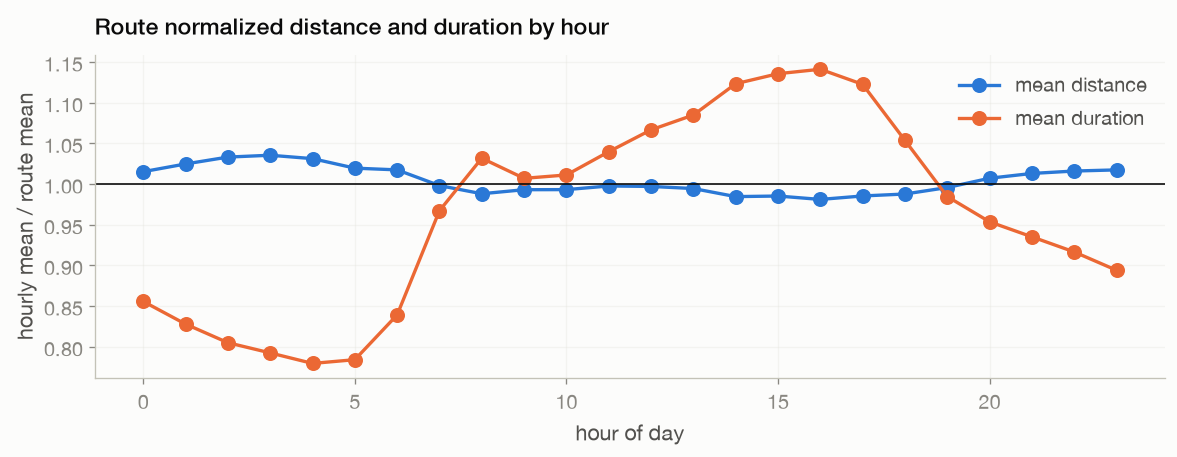

In [19]:
pair_stability = con.sql(f"""
WITH hourly AS (
    SELECT mo.z AS zo, md.z AS zd, h,
           avg(trip_miles) AS mean_mi,
           avg(trip_time) AS mean_sec
    FROM checked
    JOIN mp mo ON checked.o = mo.lid
    JOIN mp md ON checked.d = md.lid
    WHERE {TIER_A}
    GROUP BY 1, 2, 3
    HAVING count(*) >= 100
)
SELECT zo, zd,
       stddev_pop(mean_mi) / avg(mean_mi) AS cv_distance,
       stddev_pop(mean_sec) / avg(mean_sec) AS cv_duration
FROM hourly
GROUP BY 1, 2
HAVING count(*) >= 12
""").df()

stability_summary = pd.DataFrame([
    {
        "measure": "mean distance",
        "routes": len(pair_stability),
        "median_cv": pair_stability.cv_distance.median(),
        "p90_cv": pair_stability.cv_distance.quantile(0.90),
        "maximum_cv": pair_stability.cv_distance.max(),
    },
    {
        "measure": "mean duration",
        "routes": len(pair_stability),
        "median_cv": pair_stability.cv_duration.median(),
        "p90_cv": pair_stability.cv_duration.quantile(0.90),
        "maximum_cv": pair_stability.cv_duration.max(),
    },
]).round(3)
display(stability_summary)

hour_pattern = con.sql(f"""
WITH hourly AS (
    SELECT mo.z AS zo, md.z AS zd, h,
           avg(trip_miles) AS mean_mi,
           avg(trip_time) AS mean_sec
    FROM checked
    JOIN mp mo ON checked.o = mo.lid
    JOIN mp md ON checked.d = md.lid
    WHERE {TIER_A}
    GROUP BY 1, 2, 3
    HAVING count(*) >= 100
),
route AS (
    SELECT mo.z AS zo, md.z AS zd,
           avg(trip_miles) AS route_mi,
           avg(trip_time) AS route_sec
    FROM checked
    JOIN mp mo ON checked.o = mo.lid
    JOIN mp md ON checked.d = md.lid
    WHERE {TIER_A}
    GROUP BY 1, 2
)
SELECT h, count(*) AS routes,
       median(mean_mi / route_mi) AS distance_ratio,
       median(mean_sec / route_sec) AS duration_ratio
FROM hourly JOIN route USING (zo, zd)
GROUP BY 1 ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hour_pattern.h, hour_pattern.distance_ratio, marker="o", label="mean distance")
ax.plot(hour_pattern.h, hour_pattern.duration_ratio, marker="o", label="mean duration")
ax.axhline(1, color=vizstyle.INK, linewidth=1)
ax.set_xlabel("hour of day")
ax.set_ylabel("hourly mean / route mean")
ax.set_title("Route normalized distance and duration by hour", fontsize=14, loc="left")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

print(
    f"median hourly distance ratio: {hour_pattern.distance_ratio.min():.3f} to "
    f"{hour_pattern.distance_ratio.max():.3f}"
)
print(
    f"median hourly duration ratio: {hour_pattern.duration_ratio.min():.3f} to "
    f"{hour_pattern.duration_ratio.max():.3f}"
)


Across 282 routes, the median coefficient of variation is 0.042 for mean distance and 0.120 for mean
duration. The median hourly distance ratio ranges from 0.981 to 1.035, while the duration ratio ranges
from 0.779 to 1.141.

Distance has a modest time pattern, with slightly longer recorded routes overnight and slightly shorter
routes during the afternoon. The variation is substantially smaller than the corresponding duration
variation. One distance per route is therefore a reasonable simplification, although the data do not
support describing hourly distance variation as zero or as sampling noise alone.


### 6.2 Within route dispersion and dependence

The hourly result concerns the center of each route distribution. Individual trips on the same route
can still cover different distances. The analysis below reports the 90th to 10th percentile ratio, the
central 80% width relative to the median, and the Pearson correlation between distance and duration for
routes with at least 1,000 trips.


In [20]:
dense = con.sql(f"""
SELECT mo.z AS zo, md.z AS zd, count(*) AS n,
       quantile_cont(trip_miles, 0.10) AS p10,
       median(trip_miles) AS p50,
       quantile_cont(trip_miles, 0.90) AS p90,
       corr(trip_miles, trip_time) AS corr_dist_dur
FROM checked
JOIN mp mo ON checked.o = mo.lid
JOIN mp md ON checked.d = md.lid
WHERE {TIER_A}
GROUP BY 1, 2
HAVING count(*) >= 1000
""").df()
dense["p90_over_p10"] = dense.p90 / dense.p10
dense["width_over_median"] = (dense.p90 - dense.p10) / dense.p50

summary = dense[["p90_over_p10", "width_over_median", "corr_dist_dur"]].quantile(
    [0.10, 0.50, 0.90]
).T
summary.columns = ["p10", "median", "p90"]
display(summary.round(3))
print(f"routes evaluated: {len(dense)}")
print(f"routes with negative distance and duration correlation: {(dense.corr_dist_dur < 0).sum()}")


,p10,median,p90
p90_over_p10,1.558,2.094,3.434
width_over_median,0.434,0.733,1.274
corr_dist_dur,0.153,0.525,0.818


routes evaluated: 332
routes with negative distance and duration correlation: 10


For the median route, the 90th percentile distance is 2.09 times the 10th percentile, and the central
80% range is 0.73 times the route median. Median distance and duration correlation is 0.525. Ten of the
332 routes have negative correlation, so positive dependence is common but not universal.

A scalar route distance removes this within route dispersion and its dependence with duration. The next
comparison measures the resulting change in journey energy.


### 6.3 Energy effect of the implemented route mean

Three representations are compared on the 135 cells sampled in Section 5:

1. **Observed pairs:** recorded distance and duration from the same trip.
2. **Independent within cell:** recorded distances are randomly permuted within each cell while duration
   remains fixed. Marginal distributions are preserved and their dependence is removed.
3. **Implemented route mean:** every distance is replaced by the arithmetic mean for its decision zone
   pair across all hours. Duration remains observed.

The first representation is the empirical reference. The comparison isolates the distance
representation and does not include error from duration compression.


In [21]:
import tomllib

ROOT = RAW.parent.parent
pack = tomllib.loads((ROOT / "datasets" / "nyc-brooklyn" / "pack.toml").read_text())
vehicle = pack["vehicle"]
KWH_PER_MI = vehicle["consumption_wh_per_km"] * 1.609344 / 1000.0
CAPACITY_KWH = vehicle["capacity"]
OCC_KW = vehicle["hotel_load_occupied"] / 1000.0
EMPTY_KW = vehicle["hotel_load_driving_empty"] / 1000.0
print(
    f"consumption {KWH_PER_MI:.3f} kWh/mi, battery {CAPACITY_KWH} kWh, "
    f"occupied auxiliary load {OCC_KW} kW"
)

keys = ",".join(f"({int(row.zo)},{int(row.zd)},{int(row.h)})" for _, row in sample.iterrows())
cellwise = con.sql(f"""
WITH route AS (
    SELECT mo.z AS zo, md.z AS zd, avg(trip_miles) AS route_mean_mi
    FROM checked
    JOIN mp mo ON checked.o = mo.lid
    JOIN mp md ON checked.d = md.lid
    WHERE {TIER_A}
    GROUP BY 1, 2
)
SELECT mo.z AS zo, md.z AS zd, h, dt, trip_miles, trip_time, route.route_mean_mi
FROM checked
JOIN mp mo ON checked.o = mo.lid
JOIN mp md ON checked.d = md.lid
JOIN route ON route.zo = mo.z AND route.zd = md.z
WHERE {TIER_A} AND (mo.z, md.z, h) IN (VALUES {keys})
ORDER BY mo.z, md.z, h, dt, trip_time
""").df()

rng_energy = np.random.default_rng(SEED)
parts = {"observed pairs": [], "independent within cell": [], "implemented route mean": []}
for _, group in cellwise.groupby(["zo", "zd", "h"]):
    distance = group.trip_miles.to_numpy(float)
    duration_hr = group.trip_time.to_numpy(float) / 3600.0
    parts["observed pairs"].append((distance, duration_hr))
    parts["independent within cell"].append(
        (distance[rng_energy.permutation(len(distance))], duration_hr)
    )
    parts["implemented route mean"].append(
        (group.route_mean_mi.to_numpy(float), duration_hr)
    )

rows = []
reference_energy = None
for name, values in parts.items():
    distance = np.concatenate([value[0] for value in values])
    duration_hr = np.concatenate([value[1] for value in values])
    energy = distance * KWH_PER_MI + duration_hr * OCC_KW
    if reference_energy is None:
        reference_energy = energy
    rows.append({
        "method": name,
        "mean_mi": round(float(distance.mean()), 3),
        "mean_kwh": round(float(energy.mean()), 4),
        "mean_error_pct": round(100 * (energy.mean() - reference_energy.mean()) / reference_energy.mean(), 2),
        "sd_kwh": round(float(energy.std()), 4),
        "sd_error_pct": round(100 * (energy.std() - reference_energy.std()) / reference_energy.std(), 2),
        "p95_kwh": round(float(np.percentile(energy, 95)), 4),
    })
pd.DataFrame(rows)


consumption 0.349 kWh/mi, battery 85 kWh, occupied auxiliary load 4.0 kW


,method,mean_mi,mean_kwh,mean_error_pct,sd_kwh,sd_error_pct,p95_kwh
0,observed pairs,2.249,1.6826,0.00,0.9971,0.00,3.5271
1,independent within cell,2.249,1.6826,0.00,0.8821,-11.54,3.3433
2,implemented route mean,2.239,1.6791,-0.21,0.8046,-19.30,3.2297


The implemented route mean reduces average journey energy by 0.21% in this sample. It reduces
the standard deviation by 19.3% and lowers the 95th percentile from 3.53 to 3.23 kWh. Randomizing the
observed distance and duration pairing reduces the standard deviation by 11.5%, which indicates that
within cell dependence accounts for a substantial part of the difference.

The scalar distance preserves aggregate energy closely while compressing journey level variation. This
comparison does not determine the effect on vehicle state of charge or charging congestion because
those outcomes also depend on sequences of assignments and charging decisions.


### 6.4 Route distance ranges

The figure compares the stored route mean with the 10th to 90th percentile range of recorded distance
for routes containing at least 300 trips. Routes are ordered by their stored mean.


368 routes with at least 300 trips
central distance range divided by stored mean: median 0.71, maximum 1.69


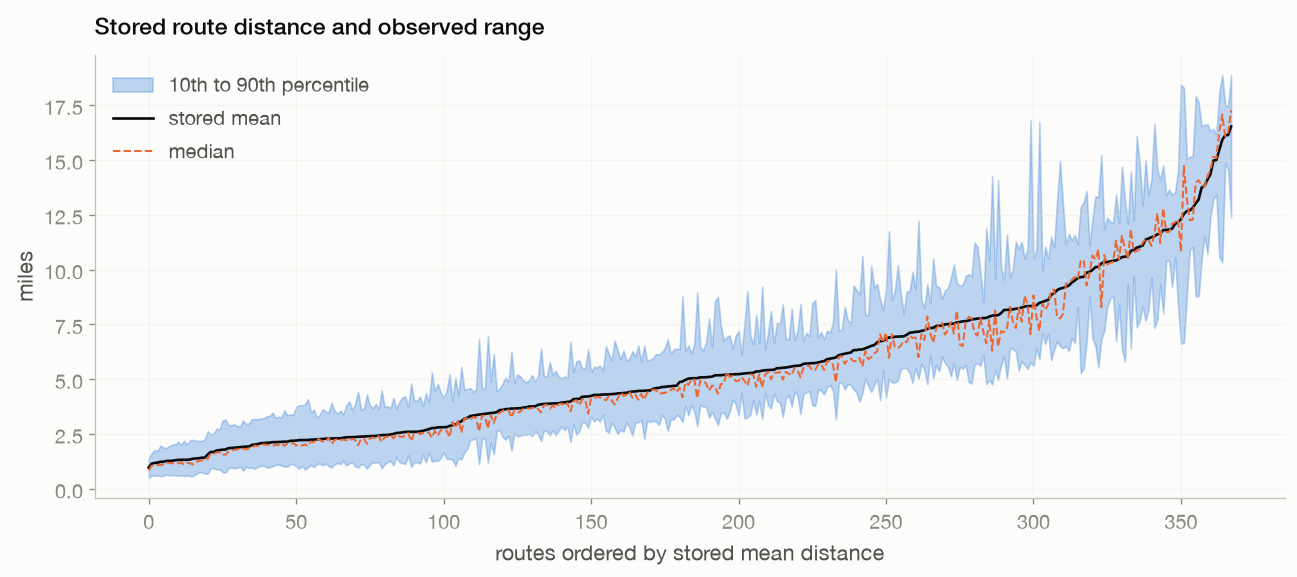

In [22]:
route_band = con.sql(f"""
SELECT mo.z AS zo, md.z AS zd, count(*) AS n,
       avg(trip_miles) AS stored_mean,
       median(trip_miles) AS stored_median,
       quantile_cont(trip_miles, 0.10) AS p10,
       quantile_cont(trip_miles, 0.90) AS p90
FROM checked
JOIN mp mo ON checked.o = mo.lid
JOIN mp md ON checked.d = md.lid
WHERE {TIER_A}
GROUP BY 1, 2
HAVING count(*) >= 300
ORDER BY stored_mean
""").df()
print(f"{len(route_band)} routes with at least 300 trips")

x = np.arange(len(route_band))
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(
    x, route_band.p10, route_band.p90,
    alpha=0.30, color=vizstyle.SERIES[0], label="10th to 90th percentile",
)
ax.plot(x, route_band.stored_mean, color=vizstyle.INK, linewidth=1.6, label="stored mean")
ax.plot(
    x, route_band.stored_median, color=vizstyle.SERIES[1], linewidth=1.2,
    linestyle="--", label="median",
)
ax.set_xlabel("routes ordered by stored mean distance")
ax.set_ylabel("miles")
ax.set_title("Stored route distance and observed range", fontsize=14, loc="left")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

route_band["band_over_mean"] = (route_band.p90 - route_band.p10) / route_band.stored_mean
print(
    f"central distance range divided by stored mean: "
    f"median {route_band.band_over_mean.median():.2f}, "
    f"maximum {route_band.band_over_mean.max():.2f}"
)


The central distance range is 0.71 times the stored mean for the median route and reaches 1.69 for the
widest route. The stored mean reproduces the sample average by construction. It does not represent the
range of individual trips, and Section 4 shows that it can be sensitive to extreme records on sparse
routes.


### 6.5 Geometric fallback for unobserved routes

The artifact uses the mean recorded distance whenever a decision zone pair has at least one trip. For
an unobserved between zone route, the fallback is the distance between the mean taxi zone centroids of
the two decision zones. For an unobserved within zone route, it is half the radius of a circle with the
same area as the decision zone.

The comparison below applies this implemented fallback to every observed route and measures its error
against the recorded route mean.


,route_type,routes,median_recorded_over_fallback,p10_recorded_over_fallback,p90_recorded_over_fallback,median_fallback_error_pct,p90_absolute_error_pct
0,between zones,380,1.28,1.06,1.64,-21.81,39.19
1,within zone,20,2.51,2.21,3.15,-60.11,68.23


trip weighted fallback error: -23.62%


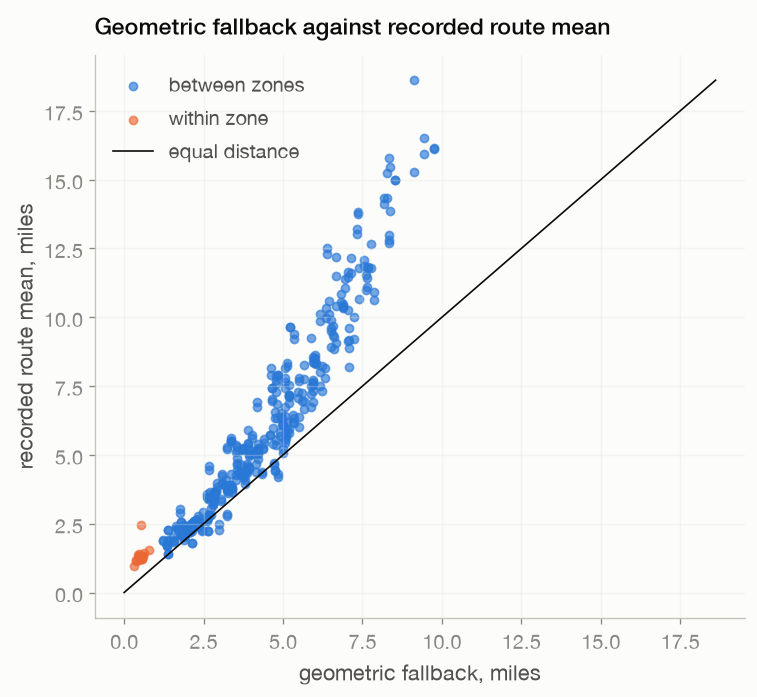

In [23]:
place_geometry = (
    bk_shp.assign(place=bk_shp.LocationID.map(ZONING))
    .groupby("place")
    .agg(cx=("cx", "mean"), cy=("cy", "mean"), area_sqmi=("area_sqmi", "sum"))
    .sort_index()
)

route_distance = con.sql(f"""
SELECT mo.z AS zo, md.z AS zd, count(*) AS n, avg(trip_miles) AS mean_mi
FROM checked
JOIN mp mo ON checked.o = mo.lid
JOIN mp md ON checked.d = md.lid
WHERE {TIER_A}
GROUP BY 1, 2
ORDER BY 1, 2
""").df()

cx = place_geometry.cx.to_numpy()
cy = place_geometry.cy.to_numpy()
radius_mi = np.sqrt(place_geometry.area_sqmi.to_numpy() / np.pi)
route_distance["fallback_mi"] = np.hypot(
    cx[route_distance.zo] - cx[route_distance.zd],
    cy[route_distance.zo] - cy[route_distance.zd],
) / 5280.0
same_zone = route_distance.zo == route_distance.zd
route_distance.loc[same_zone, "fallback_mi"] = (
    radius_mi[route_distance.loc[same_zone, "zo"].to_numpy()] / 2
)
route_distance["route_type"] = np.where(same_zone, "within zone", "between zones")
route_distance["recorded_over_fallback"] = route_distance.mean_mi / route_distance.fallback_mi
route_distance["fallback_error_pct"] = (
    100 * (route_distance.fallback_mi - route_distance.mean_mi) / route_distance.mean_mi
)

fallback_summary = (
    route_distance.groupby("route_type", observed=True)
    .agg(
        routes=("mean_mi", "size"),
        median_recorded_over_fallback=("recorded_over_fallback", "median"),
        p10_recorded_over_fallback=("recorded_over_fallback", lambda values: values.quantile(0.10)),
        p90_recorded_over_fallback=("recorded_over_fallback", lambda values: values.quantile(0.90)),
        median_fallback_error_pct=("fallback_error_pct", "median"),
        p90_absolute_error_pct=("fallback_error_pct", lambda values: values.abs().quantile(0.90)),
    )
    .round(2)
    .reset_index()
)
display(fallback_summary)

weighted_error = 100 * (
    (route_distance.fallback_mi * route_distance.n).sum()
    - (route_distance.mean_mi * route_distance.n).sum()
) / (route_distance.mean_mi * route_distance.n).sum()
print(f"trip weighted fallback error: {weighted_error:.2f}%")

fig, ax = plt.subplots(figsize=(6.5, 6))
for route_type, group in route_distance.groupby("route_type"):
    ax.scatter(group.fallback_mi, group.mean_mi, s=24, alpha=0.65, label=route_type)
limit = max(route_distance.fallback_mi.max(), route_distance.mean_mi.max())
ax.plot([0, limit], [0, limit], color=vizstyle.INK, linewidth=1, label="equal distance")
ax.set_xlabel("geometric fallback, miles")
ax.set_ylabel("recorded route mean, miles")
ax.set_title("Geometric fallback against recorded route mean", fontsize=14, loc="left")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()


All 400 decision zone pairs are observed in the current sample, so the fallback is not used by the
20 zone distance artifact. Applied hypothetically, it understates the median recorded mean by 21.8%
for between zone routes and 60.1% for within zone routes. The 90th percentile of absolute route error
is 39.2% and 68.2%, respectively. Weighted by observed trip count, the fallback understates distance by
23.6%.

The geometric value is therefore a coarse default for an unobserved route. It should not be interpreted
as an estimate with the same status as a recorded route mean. The comparison also inherits the extreme
record sensitivity described in Section 4.


### 6.6 Contribution of spatial aggregation

Distance variation within a decision zone pair can arise within an underlying TLC taxi zone pair or
between the taxi zone pairs combined by the zoning. The two components are separated using the standard
within and between group decomposition of squared variation.

The calculation is performed on recorded miles and repeated on logarithmic miles. The logarithmic
version reduces the influence of the extreme distances identified in Section 4. All underlying taxi
zone pairs are retained, and decision zone pairs require at least 300 trips.


In [24]:
def variance_decomposition(value_expression, scale):
    result = con.sql(f"""
    WITH base AS (
        SELECT mo.z AS zo, md.z AS zd, checked.o, checked.d,
               {value_expression} AS value
        FROM checked
        JOIN mp mo ON checked.o = mo.lid
        JOIN mp md ON checked.d = md.lid
        WHERE {TIER_A}
    ),
    taxi_pair AS (
        SELECT zo, zd, o, d, avg(value) AS pair_mean
        FROM base GROUP BY 1, 2, 3, 4
    ),
    decision_pair AS (
        SELECT zo, zd, count(*) AS n, avg(value) AS route_mean
        FROM base GROUP BY 1, 2 HAVING count(*) >= 300
    ),
    sums AS (
        SELECT base.zo, base.zd, decision_pair.n,
               sum(power(base.value - decision_pair.route_mean, 2)) AS total_ss,
               sum(power(base.value - taxi_pair.pair_mean, 2)) AS within_ss
        FROM base
        JOIN taxi_pair USING (zo, zd, o, d)
        JOIN decision_pair USING (zo, zd)
        GROUP BY 1, 2, 3
    )
    SELECT zo, zd, n, 1 - within_ss / total_ss AS aggregation_share
    FROM sums
    """).df()
    result["scale"] = scale
    return result

raw_decomposition = variance_decomposition("trip_miles", "recorded miles")
log_decomposition = variance_decomposition("ln(trip_miles)", "logarithmic miles")
decomposition = pd.concat([raw_decomposition, log_decomposition], ignore_index=True)

summary = (
    decomposition.groupby("scale", observed=True)
    .agg(
        routes=("aggregation_share", "size"),
        median_share=("aggregation_share", "median"),
        p90_share=("aggregation_share", lambda values: values.quantile(0.90)),
        maximum_share=("aggregation_share", "max"),
    )
    .reset_index()
)
for column in ["median_share", "p90_share", "maximum_share"]:
    summary[column] = (100 * summary[column]).round(1)
display(summary)

top_routes = raw_decomposition.nlargest(5, "aggregation_share").copy()
top_routes["aggregation_share_pct"] = (100 * top_routes.aggregation_share).round(1)
display(top_routes[["zo", "zd", "n", "aggregation_share_pct"]])


,scale,routes,median_share,p90_share,maximum_share
0,logarithmic miles,368,35.2,58.6,76.8
1,recorded miles,368,31.6,55.0,73.7


,zo,zd,n,aggregation_share_pct
202,13,9,16303,73.7
285,9,13,14982,73.6
269,0,19,1306,71.4
12,3,0,42072,70.0
239,5,18,23287,68.8


On recorded miles, aggregation accounts for 31.6% of distance variance at the median route, 55.0% at
the 90th percentile, and at most 73.7%. The logarithmic calculation gives similar results: 35.2%,
58.6%, and 76.8%.

Most distance variation at the median route remains within the underlying taxi zone pairs, while the
aggregation contributes about one third. For routes near the upper end, differences among the taxi zone
pairs combined into each decision zone account for more than half of the variance. This decomposition
measures heterogeneity introduced by the zoning; it does not identify the contiguity constraint as its
cause.


### 6.7 Summary and modeling decisions

| Subsection | Analysis and result | Conclusion | Decision |
|---|---|---|---|
| 6.1 Variation by hour | Mean distance varies less by hour than mean duration. Across 282 routes, the median coefficient of variation is 0.042 for distance and 0.120 for duration. | Hourly variation in route mean distance is present but modest. | Retain one distance mean per route. Continue to represent duration by route and hour. |
| 6.2 Within route dispersion and dependence | Individual trip distances vary substantially within a route. The median 90th to 10th percentile ratio is 2.09, and the median correlation between distance and duration is 0.525. | A route mean removes both trip level distance variation and its dependence with duration. | Treat the route mean as an aggregate representation rather than an estimate of every journey. Measure its effect on energy before retaining it. |
| 6.3 Journey energy | The implemented route mean changes average journey energy by minus 0.21%, reduces its standard deviation by 19.3%, and lowers its 95th percentile from 3.53 to 3.23 kWh. | The route mean preserves average energy closely but understates variation and the upper tail. The analysis does not establish the effect on vehicle state of charge or charging congestion. | Retain the route mean for the current artifact. Limit conclusions to aggregate energy and do not treat journey level energy variation as validated. |
| 6.4 Route distance ranges | Across 368 routes, the central 80% distance range is 0.71 times the stored mean at the median and reaches 1.69. | The arithmetic mean represents the route average but not the range of observed trips. | Continue to store the arithmetic mean required by the current model and document the omitted dispersion. |
| 6.5 Geometric fallback | All 400 routes are observed, so the fallback is unused. Applied to observed routes, it understates trip weighted mean distance by 23.6%. | The geometric fallback is materially less accurate than a recorded route mean. | Retain it only as a default for an unobserved route. The current artifact and results rely on recorded route means. |
| 6.6 Spatial aggregation | Aggregation accounts for 31.6% of distance variance at the median route and 55.0% at the 90th percentile. The logarithmic analysis gives similar results. | Combining taxi zone pairs into decision zone pairs removes a material share of route variation, although most variation at the median route remains within the original taxi zone pairs. | Retain the 20 zone representation selected in Section 3 and report spatial aggregation as a source of compressed distance variation. |

Section 6 supports retaining one arithmetic mean distance for each observed decision zone pair, without
an hourly distance index. This representation preserves mean journey energy in the tested sample and
keeps the current artifact compact. It suppresses distance variation, dependence between distance and
duration, and the upper tail of journey energy. Results that depend on individual journey energy,
vehicle state of charge paths, or charging congestion require separate validation. The geometric
fallback has no effect on the current results because all 400 routes have recorded observations.


## 7. Effect of distance representation on energy estimates

The operating model calculates journey energy as `distance × traction consumption + duration × nontraction
power`. A proportional error in distance affects only the traction term. Its effect on total energy
therefore depends on the relative size of the two terms.

This section measures that relationship, compares three route distance representations, and reports a
proportional sensitivity analysis. It does not convert average energy into charging sessions or queue
time. Those outcomes depend on the sequence of vehicle assignments, state of charge, charging policy,
and charger availability and would have to be measured in a policy evaluation.


### 7.1 Energy composition

The calculation uses the sample mean distance and duration because the quantity of interest is mean
energy. The occupied row uses the configured nontraction load for a passenger trip. The second row
holds distance and duration fixed and substitutes the configured load for an empty moving vehicle.
The second row is a controlled comparison; the TLC records do not observe empty vehicle movements.


In [25]:
import tomllib

ROOT = RAW.parent.parent
pack = tomllib.loads((ROOT / "datasets" / "nyc-brooklyn" / "pack.toml").read_text())
vehicle = pack["vehicle"]
KWH_PER_MI = vehicle["consumption_wh_per_km"] * 1.609344 / 1000.0
OCC_KW = vehicle["hotel_load_occupied"] / 1000.0
EMPTY_KW = vehicle["hotel_load_driving_empty"] / 1000.0

mean_mi, mean_hr = con.sql(f"""
SELECT avg(trip_miles), avg(trip_time) / 3600.0
FROM checked
WHERE {TIER_A}
""").fetchone()

energy_composition = []
for state, nontraction_kw in (
    ("occupied trip", OCC_KW),
    ("same movement under empty vehicle load", EMPTY_KW),
):
    traction_kwh = mean_mi * KWH_PER_MI
    nontraction_kwh = mean_hr * nontraction_kw
    total_kwh = traction_kwh + nontraction_kwh
    energy_composition.append({
        "state": state,
        "mean_mi": mean_mi,
        "mean_min": mean_hr * 60,
        "traction_kwh": traction_kwh,
        "nontraction_kwh": nontraction_kwh,
        "total_kwh": total_kwh,
        "distance_share_pct": 100 * traction_kwh / total_kwh,
    })

pd.DataFrame(energy_composition).round({
    "mean_mi": 3,
    "mean_min": 2,
    "traction_kwh": 3,
    "nontraction_kwh": 3,
    "total_kwh": 3,
    "distance_share_pct": 1,
})


,state,mean_mi,mean_min,traction_kwh,nontraction_kwh,total_kwh,distance_share_pct
0,occupied trip,2.647,14.83,0.925,0.988,1.913,48.3
1,same movement under empty vehicle load,2.647,14.83,0.925,0.309,1.233,75.0


For an average occupied trip, traction accounts for 48.3% of estimated energy. A 1% distance
error therefore changes mean occupied trip energy by approximately 0.48% when duration is held fixed.
Under the configured empty vehicle load, the corresponding share is 75.0% for the same movement.
This higher sensitivity is a property of the configured load and the observed passenger trip geometry;
it is not an empirical estimate of empty vehicle energy use.


### 7.2 Alternative route distance representations

The comparison uses all trips in the working sample and the 20 decision zones selected in Section 3.
Observed duration is retained for each record. Distance is represented by the recorded trip distance,
the arithmetic mean or median for its decision zone pair, or the geometric fallback defined in Section
6.5. Mean energy is then calculated under the occupied vehicle load.


In [26]:
section7_routes = con.sql(f"""
SELECT mo.z AS zo, md.z AS zd, count(*) AS n,
       avg(trip_miles) AS route_mean_mi,
       median(trip_miles) AS route_median_mi
FROM checked
JOIN mp mo ON checked.o = mo.lid
JOIN mp md ON checked.d = md.lid
WHERE {TIER_A}
GROUP BY 1, 2
ORDER BY 1, 2
""").df()

section7_geometry = (
    bk_shp.assign(place=bk_shp.LocationID.map(ZONING))
    .groupby("place")
    .agg(cx=("cx", "mean"), cy=("cy", "mean"), area_sqmi=("area_sqmi", "sum"))
    .sort_index()
)
section7_cx = section7_geometry.cx.to_numpy()
section7_cy = section7_geometry.cy.to_numpy()
section7_radius = np.sqrt(section7_geometry.area_sqmi.to_numpy() / np.pi)
section7_routes["fallback_mi"] = np.hypot(
    section7_cx[section7_routes.zo] - section7_cx[section7_routes.zd],
    section7_cy[section7_routes.zo] - section7_cy[section7_routes.zd],
) / 5280.0
section7_same_zone = section7_routes.zo == section7_routes.zd
section7_routes.loc[section7_same_zone, "fallback_mi"] = (
    section7_radius[section7_routes.loc[section7_same_zone, "zo"].to_numpy()] / 2
)

con.register("section7_routes", section7_routes)
distance_means = con.sql(f"""
SELECT avg(checked.trip_miles) AS recorded_mi,
       avg(section7_routes.route_mean_mi) AS route_mean_mi,
       avg(section7_routes.route_median_mi) AS route_median_mi,
       avg(section7_routes.fallback_mi) AS fallback_mi,
       avg(checked.trip_time) / 3600.0 AS duration_hr
FROM checked
JOIN mp mo ON checked.o = mo.lid
JOIN mp md ON checked.d = md.lid
JOIN section7_routes ON section7_routes.zo = mo.z AND section7_routes.zd = md.z
WHERE {TIER_A}
""").df().iloc[0]

reference_mi = distance_means.recorded_mi
reference_kwh = reference_mi * KWH_PER_MI + distance_means.duration_hr * OCC_KW
representation_rows = []
for name, column in (
    ("recorded trip distance", "recorded_mi"),
    ("decision route mean", "route_mean_mi"),
    ("decision route median", "route_median_mi"),
    ("geometric fallback", "fallback_mi"),
):
    represented_mi = distance_means[column]
    represented_kwh = represented_mi * KWH_PER_MI + distance_means.duration_hr * OCC_KW
    representation_rows.append({
        "representation": name,
        "mean_mi": represented_mi,
        "distance_bias_pct": 100 * (represented_mi / reference_mi - 1),
        "mean_kwh": represented_kwh,
        "energy_bias_pct": 100 * (represented_kwh / reference_kwh - 1),
    })

representation_table = pd.DataFrame(representation_rows).round({
    "mean_mi": 3,
    "distance_bias_pct": 2,
    "mean_kwh": 3,
    "energy_bias_pct": 2,
})
for column in ("distance_bias_pct", "energy_bias_pct"):
    representation_table.loc[representation_table[column].abs() < 0.005, column] = 0.0
representation_table


,representation,mean_mi,distance_bias_pct,mean_kwh,energy_bias_pct
0,recorded trip distance,2.647,0.00,1.913,0.00
1,decision route mean,2.647,0.00,1.913,0.00
2,decision route median,2.511,-5.15,1.865,-2.49
3,geometric fallback,2.022,-23.62,1.695,-11.41


The decision route mean reproduces average distance and average energy in the calibration sample
by construction. The decision route median understates average distance by 5.15% and average energy by
2.49%. Applying the geometric fallback to all observed routes understates average distance by 23.62%
and average energy by 11.41%.

The arithmetic mean is the appropriate scalar when energy is additive across journeys. This result is
limited to the calibration average. As shown in Section 6.3, replacing individual distances with a
route mean still reduces the variation and upper tail of journey energy. All 400 routes are observed
in the current artifact, so the geometric fallback does not affect its energy estimates.


### 7.3 Proportional distance sensitivity

The final comparison applies a common proportional change to every recorded distance while holding
duration fixed. It isolates the mechanical sensitivity of mean occupied trip energy to distance. The
changes are scenarios, not confidence intervals for the fitted route means.


In [27]:
sensitivity_rows = []
for distance_error_pct in (-30, -20, -10, -5, 0, 5, 10, 20, 30):
    adjusted_kwh = (
        mean_mi * (1 + distance_error_pct / 100) * KWH_PER_MI
        + mean_hr * OCC_KW
    )
    sensitivity_rows.append({
        "distance_error_pct": distance_error_pct,
        "mean_kwh": adjusted_kwh,
        "energy_error_pct": 100 * (adjusted_kwh / reference_kwh - 1),
    })

pd.DataFrame(sensitivity_rows).round({"mean_kwh": 3, "energy_error_pct": 2})


,distance_error_pct,mean_kwh,energy_error_pct
0,-30,1.636,-14.50
1,-20,1.728,-9.67
2,-10,1.821,-4.83
3,-5,1.867,-2.42
4,0,1.913,0.00
5,5,1.959,2.42
6,10,2.005,4.83
7,20,2.098,9.67
8,30,2.190,14.50


A 10% distance change produces a 4.83% change in mean occupied trip energy. The relationship is
linear because duration is held fixed and distance enters the energy calculation through one additive
term. The table does not identify the effect on charging frequency, queueing, or service. Those effects
depend on vehicle trajectories and operating decisions.

### 7.4 Conclusion and modeling decision

The current artifact will continue to store the arithmetic mean distance for each observed decision
zone pair. The median would introduce downward bias in aggregate energy, while the geometric fallback
is less accurate and is unnecessary for the current 400 observed routes. A symmetric 10% distance
change provides a local sensitivity check for absolute energy results; it is not an estimated error
bound. Charging outcomes require direct evaluation in policy experiments; average energy alone is
insufficient.
The absence of observed empty vehicle movements remains a limitation for empty travel energy.


## 8. Coverage and duration fallbacks

The 20 decision zones define 9,600 origin, destination, and hour cells. A cell with at least 30 trips
stores 48 empirical duration quantiles calculated from its own records. Cells below this threshold use
the fallback hierarchy implemented in `eda/fit_travel.py`:

1. the cell itself when it contains at least 30 trips;
2. the same route in the target hour and the two adjacent hours;
3. the same route across all hours; or
4. the median quantile curve from measured cells in the same route distance band, rescaled to the
   target route distance.

Every row in the duration artifact records the source used to construct it.


### 8.1 Fallback use in the fitted artifact

The following calculation applies the implemented hierarchy to all 9,600 cells. The cell percentage
gives every origin, destination, and hour combination equal weight. The trip percentage weights cells
by observed passenger trips. Neither percentage estimates the distribution of empty vehicle or
repositioning movements.


In [28]:
RUNG_ORDER = ["measured", "neighbouring hours", "whole route", "distance prior"]


def fallback_cells(place_count, labels):
    publish(labels)
    observed_cells = con.sql(f"""
    SELECT mo.z AS zo, md.z AS zd, h, count(*) AS n
    FROM checked
    JOIN mp mo ON checked.o = mo.lid
    JOIN mp md ON checked.d = md.lid
    WHERE {TIER_A}
    GROUP BY 1, 2, 3
    ORDER BY 1, 2, 3
    """).df()

    cells = pd.MultiIndex.from_product(
        [range(place_count), range(place_count), range(24)],
        names=["zo", "zd", "h"],
    ).to_frame(index=False)
    cells = cells.merge(observed_cells, on=["zo", "zd", "h"], how="left").fillna({"n": 0})
    cells["n"] = cells.n.astype(int)

    counts = cells.n.to_numpy().reshape(place_count, place_count, 24)
    adjacent_counts = counts + np.roll(counts, 1, axis=2) + np.roll(counts, -1, axis=2)
    route_counts = np.broadcast_to(counts.sum(axis=2, keepdims=True), counts.shape)
    rungs = np.select(
        [counts >= 30, adjacent_counts >= 30, route_counts >= 30],
        RUNG_ORDER[:3],
        default=RUNG_ORDER[3],
    )
    cells["rung"] = rungs.ravel()
    return cells


fallback_20 = fallback_cells(N_PLACES, ZONING)
fallback_summary = (
    fallback_20.groupby("rung", observed=True)
    .agg(cells=("n", "size"), passenger_trips=("n", "sum"))
    .reindex(RUNG_ORDER)
    .reset_index()
)
fallback_summary["pct_cells"] = 100 * fallback_summary.cells / fallback_summary.cells.sum()
fallback_summary["pct_passenger_trips"] = (
    100 * fallback_summary.passenger_trips / fallback_summary.passenger_trips.sum()
)
fallback_summary.round({"pct_cells": 2, "pct_passenger_trips": 3})

,rung,cells,passenger_trips,pct_cells,pct_passenger_trips
0,measured,8072,7840808,84.08,99.790
1,neighbouring hours,732,13586,7.62,0.173
2,whole route,724,2852,7.54,0.036
3,distance prior,72,65,0.75,0.001


The artifact estimates 84.08% of cells directly, 7.62% from adjacent hours, 7.54% from the
whole route, and 0.75% from the distance prior. Measured cells contain 99.79% of observed passenger
trips. The 141 cells with no trips can often use adjacent hours or the full route, leaving 72 cells on
the distance prior.

The unweighted 15.92% fallback share is not a repositioning rate. Such a rate depends on the routes
and hours selected by a policy. The artifact rung provides the information needed to calculate this
rate from experiment lookups.


### 8.2 Validation against withheld cells

Fallback accuracy cannot be measured directly for cells with no observations. The validation therefore
uses the 135 stratified, well observed cells sampled in Section 5. Each target cell is withheld while
the adjacent hour, whole route, and distance prior estimates are constructed from the remaining
duration records. The route distance estimate is retained. This reproduces the implemented fallback calculations for an empty target cell while keeping
the target durations out of the estimate.

The results are a proxy for fallback performance. They may not represent genuinely sparse routes,
whose travel patterns can differ from the well observed validation cells.


In [29]:
KNOTS_48 = KNOTS["quantile sampler, 48 tail dense"]
M_PER_MILE = 1609.344
PRIOR_BINS_M = np.array([0, 1500, 3000, 5000, 8000, 12000, 20000, np.inf])

fallback_pool = con.sql(f"""
SELECT mo.z AS zo, md.z AS zd, h, trip_time, trip_miles
FROM checked
JOIN mp mo ON checked.o = mo.lid
JOIN mp md ON checked.d = md.lid
WHERE {TIER_A}
ORDER BY 1, 2, 3, 4
""").df()

duration_groups = {
    key: group.trip_time.to_numpy(dtype=float)
    for key, group in fallback_pool.groupby(["zo", "zd", "h"], sort=False)
}
route_mean_miles = fallback_pool.groupby(["zo", "zd"]).trip_miles.mean().to_dict()

measured_keys = []
measured_knots = []
measured_distance_m = []
for key, values in duration_groups.items():
    if len(values) >= 30:
        measured_keys.append(key)
        measured_knots.append(np.percentile(values, KNOTS_48, method="linear"))
        measured_distance_m.append(route_mean_miles[key[:2]] * M_PER_MILE)

measured_keys = np.asarray(measured_keys, dtype=int)
measured_knots = np.vstack(measured_knots)
measured_distance_m = np.asarray(measured_distance_m)
measured_bands = np.digitize(measured_distance_m, PRIOR_BINS_M) - 1

fallback_scores = []
for _, target in sample.iterrows():
    key = (int(target.zo), int(target.zd), int(target.h))
    zo, zd, hour = key
    truth = duration_groups[key]

    adjacent = np.concatenate([
        duration_groups.get((zo, zd, (hour - 1) % 24), np.empty(0)),
        duration_groups.get((zo, zd, (hour + 1) % 24), np.empty(0)),
    ])
    whole_route = np.concatenate([
        duration_groups.get((zo, zd, candidate_hour), np.empty(0))
        for candidate_hour in range(24)
        if candidate_hour != hour
    ])

    target_distance_m = route_mean_miles[(zo, zd)] * M_PER_MILE
    target_band = np.digitize([target_distance_m], PRIOR_BINS_M)[0] - 1
    prior_members = (
        (measured_bands == target_band)
        & ~(
            (measured_keys[:, 0] == zo)
            & (measured_keys[:, 1] == zd)
            & (measured_keys[:, 2] == hour)
        )
    )
    prior_knots = np.median(measured_knots[prior_members], axis=0)
    prior_reference_m = np.median(measured_distance_m[prior_members])
    prior_knots = prior_knots * target_distance_m / prior_reference_m

    candidates = (
        ("neighbouring hours", np.percentile(adjacent, KNOTS_48, method="linear")),
        ("whole route", np.percentile(whole_route, KNOTS_48, method="linear")),
        ("distance prior", prior_knots),
    )
    for rung, knots in candidates:
        curve = np.interp(PGRID * 100, KNOTS_48, knots)
        metrics = score(curve, truth)
        predicted_p50 = np.interp(0.50, PGRID, curve)
        observed_p50 = np.percentile(truth, 50)
        fallback_scores.append({
            "rung": rung,
            "zo": zo,
            "zd": zd,
            "h": hour,
            "crps_s": metrics["crps_s"],
            "abs_err_p50_pct": abs(100 * (predicted_p50 - observed_p50) / observed_p50),
            "abs_err_p95_pct": abs(metrics["err_p95_pct"]),
            "abs_err_p99_pct": abs(metrics["err_p99_pct"]),
            "abs_err_mean_pct": abs(metrics["err_mean_pct"]),
        })

fallback_validation = pd.DataFrame(fallback_scores)
fallback_validation_summary = (
    fallback_validation.groupby("rung", observed=True)
    .agg(
        cells=("zo", "size"),
        crps_s=("crps_s", "median"),
        abs_err_p50_pct=("abs_err_p50_pct", "median"),
        abs_err_p95_pct=("abs_err_p95_pct", "median"),
        abs_err_p99_pct=("abs_err_p99_pct", "median"),
        abs_err_mean_pct=("abs_err_mean_pct", "median"),
    )
    .reindex(RUNG_ORDER[1:])
    .round(2)
    .reset_index()
)
fallback_validation_summary

,rung,cells,crps_s,abs_err_p50_pct,abs_err_p95_pct,abs_err_p99_pct,abs_err_mean_pct
0,neighbouring hours,135,178.59,2.09,2.65,4.80,1.88
1,whole route,135,190.85,9.35,10.23,10.74,8.77
2,distance prior,135,190.57,11.17,13.72,14.21,11.48


Adjacent hours provide the closest approximation, with a median CRPS of 178.59 seconds and
median absolute errors of 2.09% at the median and 4.80% at the 99th percentile. The whole route and
distance prior have similar CRPS values near 191 seconds. Their median absolute errors are materially
larger. The whole route has an 8.77% mean error and 10.74% error at the 99th percentile; the distance
prior has corresponding errors of 11.48% and 14.21%.

The results support using adjacent hours before broader sources. They provide weaker evidence for the
ordering of the final two sources because their CRPS values are nearly equal and validation is limited
to well observed cells. The full route remains ahead of the distance prior because it preserves route
identity and has lower errors at the median, mean, and upper quantiles.

### 8.3 Conclusion and modeling decision

The implemented hierarchy is retained. Each artifact row will continue to record its source. Reports
of a policy evaluation should include the share of actual duration lookups supplied by each source,
especially for policy generated movements. The validation results describe performance on withheld,
well observed cells and will not be presented as measured accuracy for routes with no data.


## 9. Sensitivity to the number of decision zones

The current artifact uses 20 decision zones. This section compares 16, 20, and 24 zones produced by
the same contiguous Ward method. The zone count affects spatial resolution, observations per cell,
fallback use, and the variation removed by storing one distance per route. Record level filters and
shared ride exclusions are unchanged.


### 9.1 Coverage and fallback use

The table applies the implemented fallback hierarchy at each zone count. `borrowed_cells_pct` gives
each possible cell equal weight. `borrowed_passenger_trips_pct` weights cells by observed passenger
trips. Actual use by repositioning movements requires the lookup distribution generated by a policy.


In [30]:
COUNTS = (16, 20, 24)
LABELS = {place_count: contiguous_labels(place_count) for place_count in COUNTS}

coverage_rows = []
fallback_by_count = {}
for place_count in COUNTS:
    cells = fallback_cells(place_count, LABELS[place_count])
    fallback_by_count[place_count] = cells
    census = cells.rung.value_counts()
    borrowed = cells.rung != "measured"
    coverage_rows.append({
        "places": place_count,
        "cells": len(cells),
        "median_trips_observed_cell": cells.loc[cells.n > 0, "n"].median(),
        "empty_cells_pct": 100 * (cells.n == 0).mean(),
        "measured_cells_pct": 100 * (cells.rung == "measured").mean(),
        "neighbouring_hours_pct": 100 * census.get("neighbouring hours", 0) / len(cells),
        "whole_route_pct": 100 * census.get("whole route", 0) / len(cells),
        "distance_prior_pct": 100 * census.get("distance prior", 0) / len(cells),
        "borrowed_cells_pct": 100 * borrowed.mean(),
        "borrowed_passenger_trips_pct": 100 * cells.loc[borrowed, "n"].sum() / cells.n.sum(),
    })

publish(ZONING)
coverage_by_count = pd.DataFrame(coverage_rows)
coverage_by_count.round({
    "median_trips_observed_cell": 0,
    "empty_cells_pct": 2,
    "measured_cells_pct": 2,
    "neighbouring_hours_pct": 2,
    "whole_route_pct": 2,
    "distance_prior_pct": 2,
    "borrowed_cells_pct": 2,
    "borrowed_passenger_trips_pct": 3,
})

,places,cells,median_trips_observed_cell,empty_cells_pct,measured_cells_pct,neighbouring_hours_pct,whole_route_pct,distance_prior_pct,borrowed_cells_pct,borrowed_passenger_trips_pct
0,16,6144,334.0,0.00,97.10,2.82,0.08,0.00,2.90,0.044
1,20,9600,200.0,1.47,84.08,7.62,7.54,0.75,15.92,0.210
2,24,13824,133.0,1.61,78.19,12.10,8.84,0.87,21.81,0.462


Increasing the count reduces the median observations per observed cell from 334 at 16 zones to
133 at 24 zones. The unweighted share of cells requiring a fallback rises from 2.90% to 21.81%.
Observed passenger trips in those cells remain uncommon, increasing from 0.044% to 0.462%.

These values establish coverage under two explicit weighting schemes. They do not establish how often
a repositioning policy uses a fallback. Twenty zones occupy the middle of the observed range, with
84.08% of cells measured directly and 0.210% of passenger trips in borrowed cells.


### 9.2 Duration representation across zone counts

The candidate comparison from Section 5 is repeated for each count. Each count uses its own stratified
sample of eligible cells and the same five consecutive date blocks. Fold results are first reduced to
one result per cell so that the cell remains the independent unit. Kernel density estimation is omitted
because it is retained only as a nondeployable reference in Section 5.


In [31]:
SENSITIVITY_CANDIDATES = (
    [(name, lambda train, knots=knots: curve_from_knots(train, knots))
     for name, knots in KNOTS.items()]
    + [
        ("gamma fitted", lambda train: curve_from_dist(train, stats.gamma)),
        ("lognormal fitted", lambda train: curve_from_dist(train, stats.lognorm)),
    ]
)
MAX_TEST_PER_FOLD = 600


def compare_storage_at_count(place_count, per_stratum=2):
    publish(LABELS[place_count])
    eligible = con.sql(f"""
    SELECT mo.z AS zo, md.z AS zd, h, count(*) AS n,
           avg(crow_mi) AS crow_mi, count(DISTINCT dt) AS dates
    FROM checked
    JOIN mp mo ON checked.o = mo.lid
    JOIN mp md ON checked.d = md.lid
    WHERE {TIER_A}
    GROUP BY 1, 2, 3
    HAVING count(*) >= 400 AND count(DISTINCT dt) >= 25
    ORDER BY 1, 2, 3
    """).df()
    eligible["kind"] = np.where(eligible.zo == eligible.zd, "same zone", "between zones")
    eligible["volume"] = pd.qcut(eligible.n, 3, labels=["low", "middle", "high"])
    eligible["distance"] = pd.qcut(
        eligible.crow_mi.rank(method="first"), 3, labels=["near", "middle", "far"]
    )
    eligible["time_of_day"] = pd.cut(
        eligible.h,
        [-1, 5, 11, 17, 23],
        labels=["night", "morning", "afternoon", "evening"],
    )
    selected = pd.concat([
        group.sample(min(len(group), per_stratum), random_state=SEED + place_count)
        for _, group in eligible.groupby(
            ["kind", "volume", "distance", "time_of_day"], observed=True
        )
    ]).reset_index(drop=True)

    selected_keys = ",".join(
        f"({int(row.zo)},{int(row.zd)},{int(row.h)})"
        for _, row in selected.iterrows()
    )
    selected_trips = con.sql(f"""
    SELECT mo.z AS zo, md.z AS zd, h, dt, trip_time
    FROM checked
    JOIN mp mo ON checked.o = mo.lid
    JOIN mp md ON checked.d = md.lid
    WHERE {TIER_A} AND (mo.z, md.z, h) IN (VALUES {selected_keys})
    ORDER BY 1, 2, 3, 4, 5
    """).df()

    results = []
    for (zo, zd, hour), group in selected_trips.groupby(["zo", "zd", "h"]):
        for fold_number, held_out in enumerate(FOLDS):
            test_values = group.trip_time[group.dt.isin(held_out)].to_numpy(dtype=float)
            train_values = group.trip_time[~group.dt.isin(held_out)].to_numpy(dtype=float)
            if len(test_values) < 40 or len(train_values) < 150:
                continue
            if len(test_values) > MAX_TEST_PER_FOLD:
                sample_seed = (
                    SEED
                    + place_count * 100000
                    + int(zo) * 1000
                    + int(zd) * 40
                    + int(hour) * 5
                    + fold_number
                )
                test_values = np.random.default_rng(sample_seed).choice(
                    test_values, MAX_TEST_PER_FOLD, replace=False
                )
            for candidate, build in SENSITIVITY_CANDIDATES:
                metrics = score(build(train_values), test_values)
                if metrics is not None:
                    results.append({
                        "places": place_count,
                        "candidate": candidate,
                        "zo": zo,
                        "zd": zd,
                        "h": hour,
                        "fold": fold_number,
                        **metrics,
                    })
    return pd.DataFrame(results), len(selected)


storage_results = []
sample_sizes = {}
for place_count in COUNTS:
    count_results, sample_size = compare_storage_at_count(place_count)
    storage_results.append(count_results)
    sample_sizes[place_count] = sample_size
    print(f"{place_count} zones: {sample_size} cells")

publish(ZONING)
storage_results = pd.concat(storage_results, ignore_index=True)
storage_results["abs_err_p99_pct"] = storage_results.err_p99_pct.abs()
storage_cells = (
    storage_results.groupby(["places", "candidate", "zo", "zd", "h"], observed=True)
    .agg(
        folds=("fold", "size"),
        crps_s=("crps_s", "median"),
        abs_err_p99_pct=("abs_err_p99_pct", "median"),
        pit_gap=("pit_gap", "median"),
    )
    .reset_index()
)
storage_by_count = (
    storage_cells.groupby(["places", "candidate"], observed=True)
    .agg(
        cells=("zo", "size"),
        crps_s=("crps_s", "median"),
        abs_err_p99_pct=("abs_err_p99_pct", "median"),
        pit_gap=("pit_gap", "median"),
    )
    .round(2)
    .reset_index()
    .sort_values(["places", "abs_err_p99_pct"])
)
storage_by_count

16 zones: 90 cells
20 zones: 90 cells
24 zones: 96 cells


,places,candidate,cells,crps_s,abs_err_p99_pct,pit_gap
4,16,"quantile sampler, 48 tail dense",90,180.49,8.35,0.07
0,16,gamma fitted,90,180.86,9.13,0.07
2,16,"quantile sampler, 101 even",90,180.46,9.31,0.07
1,16,lognormal fitted,90,181.16,15.98,0.07
3,16,"quantile sampler, 21 even",90,180.75,69.88,0.07
9,20,"quantile sampler, 48 tail dense",90,176.09,9.39,0.06
5,20,gamma fitted,90,176.28,10.36,0.07
7,20,"quantile sampler, 101 even",90,176.07,10.44,0.06
6,20,lognormal fitted,90,177.41,15.17,0.07
8,20,"quantile sampler, 21 even",90,176.64,55.32,0.06


The 48 point empirical representation remains competitive at every zone count. Its median
absolute 99th percentile error is between approximately 8% and 10%, close to the gamma and 101 point
alternatives. Differences in median CRPS among these three candidates are less than one second at each
count. The 21 point grid has substantially larger upper tail error, while the lognormal fit is
consistently less accurate in the upper tail.

The result supports retaining the 48 point empirical representation across the evaluated counts. It
does not identify a unique statistical optimum; gamma and the 101 point grid remain comparable. The
selection continues to reflect empirical representation and lower storage than the 101 point grid.


### 9.3 Distance and energy representation across zone counts

For each count, recorded trip distance is replaced by the arithmetic mean or median of its decision
zone pair. Duration remains observed. The comparison reports bias in average energy and the change in
the standard deviation and 95th percentile when the route mean replaces individual distances.


In [32]:
energy_count_rows = []
for place_count in COUNTS:
    publish(LABELS[place_count])
    values = con.sql(f"""
    WITH route AS (
        SELECT mo.z AS zo, md.z AS zd,
               avg(trip_miles) AS mean_mi,
               median(trip_miles) AS median_mi
        FROM checked
        JOIN mp mo ON checked.o = mo.lid
        JOIN mp md ON checked.d = md.lid
        WHERE {TIER_A}
        GROUP BY 1, 2
    ), energy AS (
        SELECT
            checked.trip_miles * {KWH_PER_MI} + checked.trip_time / 3600.0 * {OCC_KW}
                AS observed_kwh,
            route.mean_mi * {KWH_PER_MI} + checked.trip_time / 3600.0 * {OCC_KW}
                AS mean_route_kwh,
            route.median_mi * {KWH_PER_MI} + checked.trip_time / 3600.0 * {OCC_KW}
                AS median_route_kwh,
            checked.trip_miles AS observed_mi,
            route.mean_mi AS mean_route_mi,
            route.median_mi AS median_route_mi
        FROM checked
        JOIN mp mo ON checked.o = mo.lid
        JOIN mp md ON checked.d = md.lid
        JOIN route ON route.zo = mo.z AND route.zd = md.z
        WHERE {TIER_A}
    )
    SELECT avg(observed_mi), avg(mean_route_mi), avg(median_route_mi),
           avg(observed_kwh), avg(mean_route_kwh), avg(median_route_kwh),
           stddev_pop(observed_kwh), stddev_pop(mean_route_kwh),
           quantile_cont(observed_kwh, 0.95), quantile_cont(mean_route_kwh, 0.95)
    FROM energy
    """).fetchone()

    (observed_mi, mean_mi, median_mi, observed_kwh, mean_kwh, median_kwh,
     observed_sd, mean_sd, observed_p95, mean_p95) = values
    energy_count_rows.append({
        "places": place_count,
        "routes": place_count ** 2,
        "mean_distance_bias_pct": 100 * (mean_mi / observed_mi - 1),
        "median_distance_bias_pct": 100 * (median_mi / observed_mi - 1),
        "mean_energy_bias_pct": 100 * (mean_kwh / observed_kwh - 1),
        "median_energy_bias_pct": 100 * (median_kwh / observed_kwh - 1),
        "energy_sd_change_pct": 100 * (mean_sd / observed_sd - 1),
        "energy_p95_change_pct": 100 * (mean_p95 / observed_p95 - 1),
    })

publish(ZONING)
energy_by_count = pd.DataFrame(energy_count_rows).round(2)
for column in ("mean_distance_bias_pct", "mean_energy_bias_pct"):
    energy_by_count.loc[energy_by_count[column].abs() < 0.005, column] = 0.0
energy_by_count

,places,routes,mean_distance_bias_pct,median_distance_bias_pct,mean_energy_bias_pct,median_energy_bias_pct,energy_sd_change_pct,energy_p95_change_pct
0,16,256,0.0,-5.27,0.0,-2.55,-13.91,-5.84
1,20,400,0.0,-5.15,0.0,-2.49,-12.68,-4.99
2,24,576,0.0,-4.71,0.0,-2.28,-11.40,-3.93


The arithmetic mean preserves average distance and average energy at every count by construction.
The route median understates average energy by 2.28% to 2.55%. Zone count nevertheless affects the
energy distribution. Replacing individual distances with route means reduces the energy standard
deviation by 13.91% at 16 zones, 12.68% at 20 zones, and 11.40% at 24 zones. The corresponding reduction
in the 95th percentile is 5.84%, 4.99%, and 3.93%.

Finer zones preserve more trip level variation, although they also create more cells requiring a
fallback. Average energy alone therefore does not capture the effect of zone count.

### 9.4 Conclusion and current decision

The current artifact will retain 20 decision zones. Sixteen zones provide greater direct coverage but
remove more spatial and energy variation. Twenty four zones preserve more variation but increase the
unweighted share of borrowed cells from 15.92% to 21.81%. The 20 zone result lies between these cases
and does not alter the duration representation selected in Section 5.

This comparison does not establish an optimal count because the distribution of policy generated
movements has not been measured. A future count revision should use the share of actual model
lookups supplied by each fallback source together with policy and service outcomes. Until then, 20 is
a documented working choice rather than a statistically identified optimum.


## 10. Travel artifact specification

The fitted travel inputs contain a duration distribution for each origin, destination, and hour cell,
one distance for each ordered pair of decision zones, and a duration adjustment for each day type and
hour. This section records the implemented representation and its storage requirements.


### 10.1 Duration distribution

Each duration cell stores 48 empirical quantiles in milliseconds. The percentile positions allocate
more values to the upper tail:

| Percentile range | Increment | Stored positions |
|---|---:|---:|
| 0 through 90 | 5 | 19 |
| 90.5 through 99 | 0.5 | 18 |
| 99.1 through 99.9 | 0.1 | 9 |
| 99.99 and 100 | | 2 |

A draw begins with a uniform value between 0 and 100. Linear interpolation between the two adjacent
percentile positions returns the duration. The represented distribution is therefore a piecewise linear quantile function. For the first
three sources, its upper endpoint is the largest duration among the records used. The distance
prior uses a scaled median of the source cell endpoints. No draw exceeds the stored endpoint.

The stored expectation is calculated from the same quantile function. For consecutive percentile
positions `p[i]` and `p[i+1]` with durations `q[i]` and `q[i+1]`, their contribution is
`(p[i+1] - p[i]) / 100 × (q[i] + q[i+1]) / 2`. Summing these contributions gives the exact mean of
the represented piecewise linear distribution. The expectation and random draws therefore describe
the same stored object.


The tail dense positions reduce the upper tail error found for the 21 point grid in Sections 5
and 9. They do not remove sensitivity to the sample maximum. Section 4 measures the effect of extreme
records, and Section 8 records whether a cell was measured directly or constructed from a fallback.


### 10.2 Distance and adjustment files

The distance artifact contains one arithmetic mean distance for each of the 400 ordered decision zone
pairs. All routes are observed in the current calibration sample. The file also retains a geometric reference and identifies whether a recorded mean or fallback
supplied the stored distance. For an unobserved route between zones, the fallback is the distance
between zone centroids. For an unobserved route within a zone, it is half the zone radius.

The duration file contains 9,600 cells, their trip counts, expectations, quantiles, and fallback
sources. The day type file contains 96 adjustment factors, one for each combination of four day types
and 24 hours. Section 11 evaluates those factors.


### 10.3 Artifact inventory

The inventory reports the current CSV files rather than an estimate based only on numeric fields.
File size includes identifiers, counts, fallback labels, delimiters, and column names.


In [33]:
artifact_directory = ROOT / "datasets" / "nyc-brooklyn" / "artifacts"
artifact_descriptions = (
    ("duration-20-v1.csv", "48 quantiles and one expectation per cell"),
    ("distance-20-v1.csv", "stored distance, geometric reference, and source per route"),
    ("daytype-20-v1.csv", "factor and supporting counts per day type and hour"),
)

artifact_rows = []
for filename, contents in artifact_descriptions:
    artifact_path = artifact_directory / filename
    with artifact_path.open() as artifact_file:
        row_count = sum(1 for _ in artifact_file) - 1
    artifact_rows.append({
        "artifact": filename,
        "rows": row_count,
        "contents": contents,
        "size_mib": artifact_path.stat().st_size / 1024 ** 2,
    })

artifact_inventory = pd.DataFrame(artifact_rows)
print(f"travel CSV total: {artifact_inventory.size_mib.sum():.3f} MiB")
artifact_inventory.round({"size_mib": 3})

travel CSV total: 3.728 MiB


,artifact,rows,contents,size_mib
0,duration-20-v1.csv,9600,48 quantiles and one expectation per cell,3.712
1,distance-20-v1.csv,400,"stored distance, geometric reference, and sour...",0.011
2,daytype-20-v1.csv,96,factor and supporting counts per day type and ...,0.005


The three travel CSVs occupy 3.73 MiB. Storage at this scale does not justify further
compression. The choice among the 48 point grid, 101 point grid, and fitted distributions rests on
their statistical behavior and representation, rather than file size alone.

### 10.4 Reproducibility and modeling decision

The current duration CSV is not self describing. The columns `q00` through `q47` preserve the order of
the quantiles but do not record their percentile positions. Those positions are defined by `KNOTS` in
`eda/fit_travel.py`. The provenance file records the number of positions and the output file hashes,
but not the positions themselves or a revision of the fitting code. Reproducing the distribution
therefore requires the artifact and the corresponding fitting code.

The current artifact retains the 48 point empirical duration representation, an expectation computed
from the same quantile function, the arithmetic mean distance for each observed route, and a source
label for every duration and distance row. Recording the percentile positions in the artifact schema
remains a reproducibility improvement for a future revision.


## 11. Variation by day of week

The duration cells fitted in earlier sections pool all calibration dates. Demand uses four day types,
but travel time reflects a different process and requires a separate assessment. This section examines
weekday profiles, compares candidate groupings, and evaluates whether day type should be represented by
separate cell distributions or a shared hourly adjustment.

For this comparison, hours from midnight through 03:00 are assigned to the preceding demand date using
the 04:00 classification boundary. This convention does not constrain when an evaluation period
begins. The pickup month
remains unchanged when monthly calibration samples are compared.


### 11.1 Weekday travel profiles

The comparison uses decision zone and hour cells containing at least 30 trips on every weekday. For
each cell, typical speed is calculated from its median distance and median duration. The table reports
the median of these cell values at selected hours. Duration profiles are calculated within each cell
before aggregation so that differences in route composition do not determine the weekday pattern.


In [34]:
DAY_LABELS = {0: "Sun", 1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"}
WEEKDAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

publish(ZONING)
con.execute("""
CREATE OR REPLACE VIEW bk_dow AS
SELECT o, d, h, trip_time AS duration_s, trip_miles,
       dt AS pickup_date,
       strftime(dt, '%Y-%m') AS pickup_month,
       CASE WHEN h < 4 THEN dt - INTERVAL 1 DAY ELSE dt END AS simulation_date,
       dayofweek(CASE WHEN h < 4 THEN dt - INTERVAL 1 DAY ELSE dt END) AS dow
FROM bk
""")

weekday_cells = con.sql("""
SELECT dow, mo.z AS zo, md.z AS zd, h, count(*) AS n,
       median(duration_s) AS median_s,
       median(trip_miles) AS median_mi
FROM bk_dow
JOIN mp mo ON bk_dow.o = mo.lid
JOIN mp md ON bk_dow.d = md.lid
GROUP BY 1, 2, 3, 4
HAVING count(*) >= 30
ORDER BY 1, 2, 3, 4
""").df()

weekday_count = weekday_cells.groupby(["zo", "zd", "h"]).dow.nunique()
complete_keys = set(weekday_count[weekday_count == 7].index)
weekday_complete = weekday_cells[
    [key in complete_keys for key in zip(weekday_cells.zo, weekday_cells.zd, weekday_cells.h)]
].copy()

weekday_complete["kph"] = (
    weekday_complete.median_mi * 1.609344 / (weekday_complete.median_s / 3600.0)
)
weekday_speed = weekday_complete.groupby(["dow", "h"]).kph.median().unstack("dow")
weekday_speed.columns = [DAY_LABELS[column] for column in weekday_speed.columns]
weekday_speed = weekday_speed[WEEKDAYS]

weekday_complete["duration_ratio"] = (
    weekday_complete.median_s
    / weekday_complete.groupby(["zo", "zd", "h"]).median_s.transform("mean")
)
weekday_profile = (
    weekday_complete.groupby(["dow", "h"]).duration_ratio.median().unstack("dow")
)
weekday_profile.columns = [DAY_LABELS[column] for column in weekday_profile.columns]
weekday_profile = weekday_profile[WEEKDAYS]

print(f"{len(complete_keys):,} decision zone and hour cells meet the weekday coverage rule")
weekday_speed.loc[[0, 5, 8, 12, 17, 23]].round(1)

3,760 decision zone and hour cells meet the weekday coverage rule


,Mon,Tue,Wed,Thu,Fri,Sat,Sun
h,,,,,,,
0,20.2,19.8,19.6,19.4,18.8,18.6,19.9
5,20.4,20.0,20.4,20.2,20.6,20.4,20.6
8,14.9,14.6,14.8,15.1,15.4,19.1,19.7
12,15.6,15.1,15.1,14.8,15.1,16.4,16.8
17,14.6,14.6,14.1,13.8,14.5,16.3,16.8
23,19.8,19.6,19.1,19.0,18.1,18.2,19.4


At 08:00, median cell speed is 19.7 km/h on Sunday and 14.6 km/h on Tuesday, a difference of
approximately 35%. At 05:00 the weekday values lie between 20.0 and 20.6 km/h. Around midnight,
Friday and Saturday are slower than Monday. The pattern is concentrated in commuting hours and late
evening travel rather than expressed as a constant weekday offset.

The analysis establishes systematic weekday variation among the 3,760 cells meeting the coverage
rule. Cells with lower volume are not represented in this comparison.


### 11.2 Day type grouping

Candidate groupings are evaluated against the seven weekday duration profiles. The residual is the
absolute difference between a weekday profile and the mean profile assigned to its group, measured in
percentage points of duration. This is a descriptive comparison of the observed profiles rather than
a significance test.


In [35]:
DAY_GROUPINGS = {
    "one pooled group": dict.fromkeys(WEEKDAYS, 0),
    "weekday and weekend": {
        "Mon": 0, "Tue": 0, "Wed": 0, "Thu": 0, "Fri": 0, "Sat": 1, "Sun": 1
    },
    "Mon to Fri, Sat, Sun": {
        "Mon": 0, "Tue": 0, "Wed": 0, "Thu": 0, "Fri": 0, "Sat": 1, "Sun": 2
    },
    "Mon to Thu, Fri, Sat, Sun": {
        "Mon": 0, "Tue": 0, "Wed": 0, "Thu": 0, "Fri": 1, "Sat": 2, "Sun": 3
    },
    "demand four types": {
        "Mon": 0, "Tue": 0, "Wed": 0, "Thu": 1, "Fri": 1, "Sat": 2, "Sun": 3
    },
    "one group per weekday": {day: index for index, day in enumerate(WEEKDAYS)},
}

grouping_rows = []
for grouping, labels in DAY_GROUPINGS.items():
    assigned_profile = weekday_profile.T.groupby(pd.Series(labels)).transform("mean").T
    residual = (100 * (weekday_profile - assigned_profile)).abs()
    grouping_rows.append({
        "grouping": grouping,
        "groups": len(set(labels.values())),
        "mean_residual_pp": residual.to_numpy().mean(),
        "maximum_residual_pp": residual.to_numpy().max(),
    })

grouping_comparison = pd.DataFrame(grouping_rows)
grouping_comparison.round({"mean_residual_pp": 2, "maximum_residual_pp": 2})

,grouping,groups,mean_residual_pp,maximum_residual_pp
0,one pooled group,1,3.67,16.61
1,weekday and weekend,2,1.99,6.69
2,"Mon to Fri, Sat, Sun",3,1.34,6.69
3,"Mon to Thu, Fri, Sat, Sun",4,0.92,4.62
4,demand four types,4,0.91,3.47
5,one group per weekday,7,0.00,0.00


The four demand day types produce a mean residual of 0.91 percentage points and a maximum of
3.47 points. The alternative that separates Friday from Monday through Thursday produces a mean of
0.92 points and a maximum of 4.62 points. Both are substantially more accurate than the weekday and
weekend division.

The demand grouping is retained for travel: Monday through Wednesday, Thursday and Friday, Saturday,
and Sunday. It has the lowest residual among the evaluated groupings with fewer than seven categories
and uses one day type definition across the fitted demand and travel inputs.


### 11.3 Separate distributions or shared factors

A separate distribution for each day type would expand the duration matrix from 9,600 to 38,400 cells.
A shared factor retains the pooled distribution and applies one adjustment for each day type and hour,
requiring 96 factors. The comparison below reports coverage under a full split and decomposes the
observed day type variation into a shared hourly component and a route specific remainder.


In [36]:
DAY_TYPE_EXPRESSION = """
CASE
    WHEN dow IN (1, 2, 3) THEN 'mon_wed'
    WHEN dow IN (4, 5) THEN 'thu_fri'
    WHEN dow = 6 THEN 'sat'
    ELSE 'sun'
END
"""

coverage_rows = []
for window, months in (
    ("June", ["2025-06"]),
    ("June and July", list(CALIBRATION_MONTHS)),
):
    month_values = ", ".join(f"'{month}'" for month in months)
    pooled_counts = con.sql(f"""
    SELECT mo.z AS zo, md.z AS zd, h, count(*) AS n
    FROM bk_dow
    JOIN mp mo ON bk_dow.o = mo.lid
    JOIN mp md ON bk_dow.d = md.lid
    WHERE pickup_month IN ({month_values})
    GROUP BY 1, 2, 3
    """).df()
    split_counts = con.sql(f"""
    SELECT {DAY_TYPE_EXPRESSION} AS day_type,
           mo.z AS zo, md.z AS zd, h, count(*) AS n
    FROM bk_dow
    JOIN mp mo ON bk_dow.o = mo.lid
    JOIN mp md ON bk_dow.d = md.lid
    WHERE pickup_month IN ({month_values})
    GROUP BY 1, 2, 3, 4
    """).df()
    coverage_rows.append({
        "window": window,
        "trips": int(pooled_counts.n.sum()),
        "pooled_measured_pct": 100 * (pooled_counts.n >= 30).sum() / 9600,
        "pooled_median_trips": pooled_counts.n.median(),
        "split_measured_pct": 100 * (split_counts.n >= 30).sum() / 38400,
        "split_median_trips": split_counts.n.median(),
    })

coverage_comparison = pd.DataFrame(coverage_rows)

weekday_complete["day_type"] = weekday_complete.dow.map({
    1: "mon_wed", 2: "mon_wed", 3: "mon_wed",
    4: "thu_fri", 5: "thu_fri", 6: "sat", 0: "sun",
})
day_type_cells = (
    weekday_complete.groupby(["zo", "zd", "h", "day_type"], as_index=False).median_s.median()
)
log_duration = np.log(day_type_cells.median_s)
cell_mean = log_duration.groupby(
    [day_type_cells.zo, day_type_cells.zd, day_type_cells.h]
).transform("mean")
day_type_residual = log_duration - cell_mean
shared_component = day_type_residual.groupby(
    [day_type_cells.day_type, day_type_cells.h]
).transform("mean")
shared_explained_pct = 100 * (
    1
    - ((day_type_residual - shared_component) ** 2).sum()
    / (day_type_residual ** 2).sum()
)
route_remainder_pct = 100 * (
    np.exp(np.sqrt(((day_type_residual - shared_component) ** 2).mean())) - 1
)

weekday_log_duration = np.log(weekday_complete.median_s)
type_mean = weekday_log_duration.groupby([
    weekday_complete.zo,
    weekday_complete.zd,
    weekday_complete.h,
    weekday_complete.day_type,
]).transform("mean")
within_type_pct = 100 * (
    np.exp(np.sqrt(((weekday_log_duration - type_mean) ** 2).mean())) - 1
)

print(f"shared day type and hour factors explain {shared_explained_pct:.1f}% of between type variation")
print(f"route specific remainder: {route_remainder_pct:.2f}% in duration terms")
print(f"variation among weekdays within a day type: {within_type_pct:.2f}%")
coverage_comparison.round({
    "pooled_measured_pct": 1,
    "pooled_median_trips": 0,
    "split_measured_pct": 1,
    "split_median_trips": 0,
})

shared day type and hour factors explain 54.7% of between type variation
route specific remainder: 5.08% in duration terms
variation among weekdays within a day type: 3.44%


,window,trips,pooled_measured_pct,pooled_median_trips,split_measured_pct,split_median_trips
0,June,4017739,74.5,104.0,44.5,27.0
1,June and July,7857311,84.1,200.0,57.9,49.0


With both months, 84.1% of pooled cells meet the 30 trip threshold, compared with 57.9% after
a four type split. The median observed cell falls from 200 to 49 trips. Shared day type and hour factors
explain 54.7% of the between type variation among the cells used in the decomposition. The route
specific remainder is 5.08% in duration terms, and variation among weekdays within the selected day
types is 3.44%.

The shared factor is retained. It represents the common day type pattern without reducing cell
coverage. Route specific differences and differences among weekdays within a type remain outside the
model.


### 11.4 Stability across months

The factor calculation follows `fit_travel.py`: each eligible cell contributes the ratio of its day
type median to its pooled median, the factor is the median ratio across cells, and the four factors are
normalized within each hour using observed trip shares. June and July are fitted separately. Each
month's factors are also applied to the other month's cells to provide a temporal validation of median
duration adjustment.


In [37]:
def fit_month_factors(months):
    month_values = ", ".join(f"'{month}'" for month in months)
    cells = con.sql(f"""
    SELECT pickup_month, {DAY_TYPE_EXPRESSION} AS day_type,
           mo.z AS zo, md.z AS zd, h,
           count(*) AS n, median(duration_s) AS median_s
    FROM bk_dow
    JOIN mp mo ON bk_dow.o = mo.lid
    JOIN mp md ON bk_dow.d = md.lid
    WHERE pickup_month IN ({month_values})
    GROUP BY 1, 2, 3, 4, 5
    HAVING count(*) >= 30
    """).df()
    pooled = con.sql(f"""
    SELECT pickup_month, mo.z AS zo, md.z AS zd, h,
           count(*) AS n0, median(duration_s) AS pooled_median_s
    FROM bk_dow
    JOIN mp mo ON bk_dow.o = mo.lid
    JOIN mp md ON bk_dow.d = md.lid
    WHERE pickup_month IN ({month_values})
    GROUP BY 1, 2, 3, 4
    HAVING count(*) >= 100
    """).df()
    ratios = cells.merge(pooled, on=["pickup_month", "zo", "zd", "h"])
    ratios["ratio"] = ratios.median_s / ratios.pooled_median_s
    raw = (
        ratios.groupby(["pickup_month", "day_type", "h"])
        .agg(raw_factor=("ratio", "median"), cells=("ratio", "size"))
        .reset_index()
    )
    shares = con.sql(f"""
    SELECT pickup_month, {DAY_TYPE_EXPRESSION} AS day_type, h, count(*) AS trips
    FROM bk_dow
    WHERE pickup_month IN ({month_values})
    GROUP BY 1, 2, 3
    """).df()
    factors = raw.merge(shares, on=["pickup_month", "day_type", "h"], how="right")
    factors["weight"] = factors.trips / factors.groupby(["pickup_month", "h"]).trips.transform("sum")
    normalization = (factors.raw_factor * factors.weight).groupby(
        [factors.pickup_month, factors.h]
    ).transform("sum")
    factors["factor"] = factors.raw_factor / normalization
    return factors, ratios


monthly_factors, monthly_ratios = fit_month_factors(CALIBRATION_MONTHS)
factor_wide = monthly_factors.pivot(
    index=["day_type", "h"], columns="pickup_month", values="factor"
).dropna()
factor_wide.columns = ["june", "july"]
factor_wide["gap_pp"] = 100 * (factor_wide.june - factor_wide.july)

other_month = monthly_factors[["pickup_month", "day_type", "h", "factor"]].copy()
other_month["pickup_month"] = other_month.pickup_month.map({
    "2025-06": "2025-07",
    "2025-07": "2025-06",
})
other_month = other_month.rename(columns={"factor": "other_month_factor"})
cross_month = monthly_ratios.merge(
    other_month,
    on=["pickup_month", "day_type", "h"],
)
cross_month["pooled_abs_error_pct"] = (
    100 * (1 - cross_month.ratio).abs() / cross_month.ratio
)
cross_month["adjusted_abs_error_pct"] = (
    100 * (cross_month.other_month_factor - cross_month.ratio).abs() / cross_month.ratio
)

stability_summary = pd.DataFrame([{
    "factors": len(factor_wide),
    "month_correlation": factor_wide.june.corr(factor_wide.july),
    "mean_absolute_month_gap_pp": factor_wide.gap_pp.abs().mean(),
    "maximum_month_gap_pp": factor_wide.gap_pp.abs().max(),
    "factor_span_pp": 100 * (
        factor_wide[["june", "july"]].mean(axis=1).max()
        - factor_wide[["june", "july"]].mean(axis=1).min()
    ),
    "pooled_median_abs_error_pct": cross_month.pooled_abs_error_pct.median(),
    "adjusted_median_abs_error_pct": cross_month.adjusted_abs_error_pct.median(),
    "median_error_reduction_pct": 100 * (
        1
        - cross_month.adjusted_abs_error_pct.median()
        / cross_month.pooled_abs_error_pct.median()
    ),
}])
stability_summary.round(2)

,factors,month_correlation,mean_absolute_month_gap_pp,maximum_month_gap_pp,factor_span_pp,pooled_median_abs_error_pct,adjusted_median_abs_error_pct,median_error_reduction_pct
0,96,0.97,1.22,4.38,23.56,4.19,3.3,21.35


The 96 June and July factors have a correlation of 0.97. Their mean absolute difference is
1.22 percentage points, compared with a 23.56 point span across the fitted factors. Applying one
month's factors to the other month reduces median absolute error in cell median duration from 4.19%
to 3.30%, a reduction of 21.35%.

### 11.5 Conclusion and modeling decision

Travel duration varies systematically by weekday. The four demand day types also provide the best
four category description among the candidates evaluated for travel. The fitted artifact therefore
retains pooled route and hour distributions and applies 96 normalized day type and hour factors. This
choice preserves pooled cell coverage and improves median duration estimates across months, while
leaving route specific and within type weekday variation unmodeled.


## 12. Retained modeling tradeoffs

| Choice | Reason retained | Consequence |
|---|---|---|
| Exclude matched shared rides | Their recorded movement can include an additional passenger detour that the operating model does not represent. | The travel fit does not describe matched shared service. |
| Retain event dates in the travel sample | Their effect on fitted cell medians is small, and retaining them improves support for sparse cells. | Small event specific changes remain in the baseline distributions. |
| Retain records without an additional outlier filter | Unusual duration and distance values can represent real congestion or route variation, and no independent validity label is available. | Some sparse route means remain sensitive to extreme records. |
| Use 20 contiguous decision zones | Twenty zones provide more spatial detail than 16 and greater direct cell coverage than 24. They also match the demand artifact. | The count is a working compromise rather than a statistical optimum. Aggregation removes spatial variation, and 15.9 percent of unweighted cells use a duration fallback. |
| Store 48 empirical duration quantiles | The representation preserves the observed shape and upper tail with performance comparable to larger or fitted alternatives. | Percentile positions remain defined in the fitting code rather than the CSV, so the artifact is not fully self describing. |
| Store one arithmetic mean distance per route | The mean preserves aggregate distance and mean journey energy closely while keeping the input interface compact. | Journey distance variation, its dependence with duration, and part of the upper energy tail are removed. Vehicle state of charge paths and charging contention may therefore be too regular. |
| Use adjacent hours, then the whole route, then a distance prior for sparse duration cells | Adjacent hours perform best in withheld cell validation, and the hierarchy provides a value for every modeled movement. | Validation uses withheld observations from well observed cells. Accuracy on genuinely unobserved cells and policy generated empty movements is unknown. |
| Apply day type and hour factors to pooled duration cells | Ninety six factors retain pooled cell coverage and improve cross month estimates of median duration. | Route specific day effects and differences between weekdays within a type remain unmodeled. |
| Apply passenger trip travel inputs to empty movements | Passenger trips are the only observed source with route, duration, and distance. | The records cannot establish that empty vehicle movements have the same travel distributions. Empty travel energy and timing remain unvalidated. |

These choices favor coverage, reproducibility, and a compact artifact. They compress spatial and journey
level variation. Results involving upper energy tails, vehicle state of charge trajectories, charging
queues, or frequent fallback use require corresponding sensitivity analysis.